In [1]:
## Step 0 — Install packages & imports
# Colab: install the packages we need (run once)
!pip install lightgbm shap phik holidays --quiet

# Imports
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import holidays
import shap

# Make plots inline and readable
plt.rcParams['figure.figsize'] = (12,5)
np.random.seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 22.2 MB/s eta 0:00:00


In [4]:
## Step 1 — Point the notebook to your files & list them
from google.colab import drive
import glob, os

drive.mount('/content/drive')

# Updated path and patterns based on your drive contents
DATA_DIR = "/content/drive/MyDrive/SPM"

# The file listing shows files like 'Raw_data_1Day_2024_site_...'
patterns = [
    "Raw_data_1Day_2017*.csv",
    "Raw_data_1Day_2018*.csv",
    "Raw_data_1Day_2019*.csv",
    "Raw_data_1Day_2020*.csv",
    "Raw_data_1Day_2021*.csv",
    "Raw_data_1Day_2022*.csv",
    "Raw_data_1Day_2023*.csv",
    "Raw_data_1Day_2024*.csv"
]

found_files = []
for p in patterns:
    found_files += glob.glob(os.path.join(DATA_DIR, p))

found_files = sorted(list(set(found_files)))
print(f"Files found ({len(found_files)}):", found_files)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found (8): ['/content/drive/MyDrive/SPM/Raw_data_1Day_2017_site_1437_Model_Town_Patiala_PPCB_1Day.csv', '/content/drive/MyDrive/SPM/Raw_data_1Day_2018_site_1437_Model_Town_Patiala_PPCB_1Day.csv', '/content/drive/MyDrive/SPM/Raw_data_1Day_2019_site_1437_Model_Town_Patiala_PPCB_1Day.csv', '/content/drive/MyDrive/SPM/Raw_data_1Day_2020_site_1437_Model_Town_Patiala_PPCB_1Day.csv', '/content/drive/MyDrive/SPM/Raw_data_1Day_2021_site_1437_Model_Town_Patiala_PPCB_1Day.csv', '/content/drive/MyDrive/SPM/Raw_data_1Day_2022_site_1437_Model_Town_Patiala_PPCB_1Day.csv', '/content/drive/MyDrive/SPM/Raw_data_1Day_2023_site_1437_Model_Town_Patiala_PPCB_1Day.csv', '/content/drive/MyDrive/SPM/Raw_data_1Day_2024_site_1437_Model_Town_Patiala_PPCB_1Day.csv']


In [5]:
# Step 2 — Load the data & combine files
combined = pd.concat([pd.read_csv(f) for f in found_files], ignore_index=True)
display(combined.head())
display(combined.info())

## Step 3 — Normalize column names (strip units & whitespace)
def clean_colname(col):
    c = col.strip()
    # remove unit parenthesis: "(...)" and any degree/µ symbols
    c = re.sub(r'\(.*?\)', '', c)
    c = c.replace('°', '').replace('µ', 'u').replace('/', '_').replace(' ', '_')
    c = c.replace('.', '_').replace('-', '_')
    c = re.sub(r'__+', '_', c)
    c = c.strip('_').lower()
    # common renames:
    c = c.replace('pm2_5', 'pm2_5').replace('pm25', 'pm2_5')
    c = c.replace('pm10', 'pm10')
    c = c.replace('temp', 'temperature')
    c = c.replace('rh', 'rh')  # relative humidity
    c = c.replace('ws', 'wind_speed')
    c = c.replace('wd', 'wind_dir')
    c = c.replace('sr', 'solar_radiation')
    c = c.replace('bp', 'pressure')
    c = c.replace('rf', 'rain')
    c = c.replace('ozone', 'o3')
    c = c.replace('at', 'apparent_temperature')
    return c

combined = combined.rename(columns={c: clean_colname(c) for c in combined.columns})
print("Columns after cleaning:\n", combined.columns.tolist())

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,2017-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,2017-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,2017-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,2017-01-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,2017-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            2922 non-null   object 
 1   PM2.5 (µg/m³)        2517 non-null   float64
 2   PM10 (µg/m³)         2517 non-null   float64
 3   NO (µg/m³)           2460 non-null   float64
 4   NO2 (µg/m³)          2461 non-null   float64
 5   NOx (ppb)            2472 non-null   float64
 6   NH3 (µg/m³)          2460 non-null   float64
 7   SO2 (µg/m³)          2476 non-null   float64
 8   CO (mg/m³)           2522 non-null   float64
 9   Ozone (µg/m³)        2518 non-null   float64
 10  Benzene (µg/m³)      2498 non-null   float64
 11  Toluene (µg/m³)      1996 non-null   float64
 12  Xylene (µg/m³)       0 non-null      float64
 13  O Xylene (µg/m³)     0 non-null      float64
 14  Eth-Benzene (µg/m³)  2479 non-null   float64
 15  MP-Xylene (µg/m³)    2462 non-null   f

None

Columns after cleaning:
 ['timestamp', 'pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'xylene', 'o_xylene', 'eth_benzene', 'mp_xylene', 'apparent_temperature', 'rh', 'wind_speed', 'wind_dir', 'rain', 'tot_rain', 'solar_radiapparent_temperatureion', 'pressure', 'vwind_speed']


In [6]:
# Step 2 — Load the data & combine files
combined = pd.concat([pd.read_csv(f) for f in found_files], ignore_index=True)
display(combined.head())
display(combined.info())

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,2017-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,2017-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,2017-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,2017-01-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,2017-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            2922 non-null   object 
 1   PM2.5 (µg/m³)        2517 non-null   float64
 2   PM10 (µg/m³)         2517 non-null   float64
 3   NO (µg/m³)           2460 non-null   float64
 4   NO2 (µg/m³)          2461 non-null   float64
 5   NOx (ppb)            2472 non-null   float64
 6   NH3 (µg/m³)          2460 non-null   float64
 7   SO2 (µg/m³)          2476 non-null   float64
 8   CO (mg/m³)           2522 non-null   float64
 9   Ozone (µg/m³)        2518 non-null   float64
 10  Benzene (µg/m³)      2498 non-null   float64
 11  Toluene (µg/m³)      1996 non-null   float64
 12  Xylene (µg/m³)       0 non-null      float64
 13  O Xylene (µg/m³)     0 non-null      float64
 14  Eth-Benzene (µg/m³)  2479 non-null   float64
 15  MP-Xylene (µg/m³)    2462 non-null   f

None

In [7]:
## Step 3 — Normalize column names (strip units & whitespace)
def clean_colname(col):
    c = col.strip()
    # remove unit parenthesis: "(...)" and any degree/µ symbols
    c = re.sub(r'\(.*?\)', '', c)
    c = c.replace('°', '').replace('µ', 'u').replace('/', '_').replace(' ', '_')
    c = c.replace('.', '_').replace('-', '_')
    c = re.sub(r'__+', '_', c)
    c = c.strip('_').lower()
    # common renames:
    c = c.replace('pm2_5', 'pm2_5').replace('pm25', 'pm2_5')
    c = c.replace('pm10', 'pm10')
    c = c.replace('temp', 'temperature')
    c = c.replace('rh', 'rh')  # relative humidity
    c = c.replace('ws', 'wind_speed')
    c = c.replace('wd', 'wind_dir')
    c = c.replace('sr', 'solar_radiation')
    c = c.replace('bp', 'pressure')
    c = c.replace('rf', 'rain')
    c = c.replace('ozone', 'o3')
    c = c.replace('at', 'apparent_temperature')
    return c

combined = combined.rename(columns={c: clean_colname(c) for c in combined.columns})
print("Columns after cleaning:\n", combined.columns.tolist())

Columns after cleaning:
 ['timestamp', 'pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'xylene', 'o_xylene', 'eth_benzene', 'mp_xylene', 'apparent_temperature', 'rh', 'wind_speed', 'wind_dir', 'rain', 'tot_rain', 'solar_radiapparent_temperatureion', 'pressure', 'vwind_speed']


In [11]:
## Step 4 — Find timestamp column and parse it
def find_timestamp(colnames):
    candidates = [c for c in colnames if 'time' in c or 'date' in c or 'timestamp' in c]
    return candidates[0] if candidates else None

ts_col = find_timestamp(combined.columns)
print("Detected timestamp column:", ts_col)

# parse
combined[ts_col] = pd.to_datetime(combined[ts_col], errors='coerce')
print("Parsed timestamps - null count:", combined[ts_col].isna().sum())

# drop rows without timestamp
combined = combined.dropna(subset=[ts_col]).copy()
combined = combined.sort_values(ts_col).reset_index(drop=True)
combined = combined.rename(columns={ts_col: 'timestamp'})
print("Data range:", combined['timestamp'].min(), "to", combined['timestamp'].max())

# check duplicates
dups = combined['timestamp'].duplicated().sum()
print("Duplicate timestamp rows:", dups)


Detected timestamp column: timestamp
Parsed timestamps - null count: 731
Data range: 2017-01-01 00:00:00 to 2022-12-31 00:00:00
Duplicate timestamp rows: 0


In [10]:
## Step 5 — Quick missingness report (which columns are mostly empty)

missing_pct = combined.isna().mean() * 100
missing_df = missing_pct.sort_values(ascending=False).reset_index()
missing_df.columns = ['feature', 'missing_percent']
missing_df.head(30)


,feature,missing_percent
0,xylene,100.000000
1,pressure,100.000000
2,apparent_temperature,100.000000
3,o_xylene,100.000000
4,vwind_speed,100.000000
5,toluene,31.690623
6,no,15.811088
7,nh3,15.811088
8,no2,15.776865
9,mp_xylene,15.742642


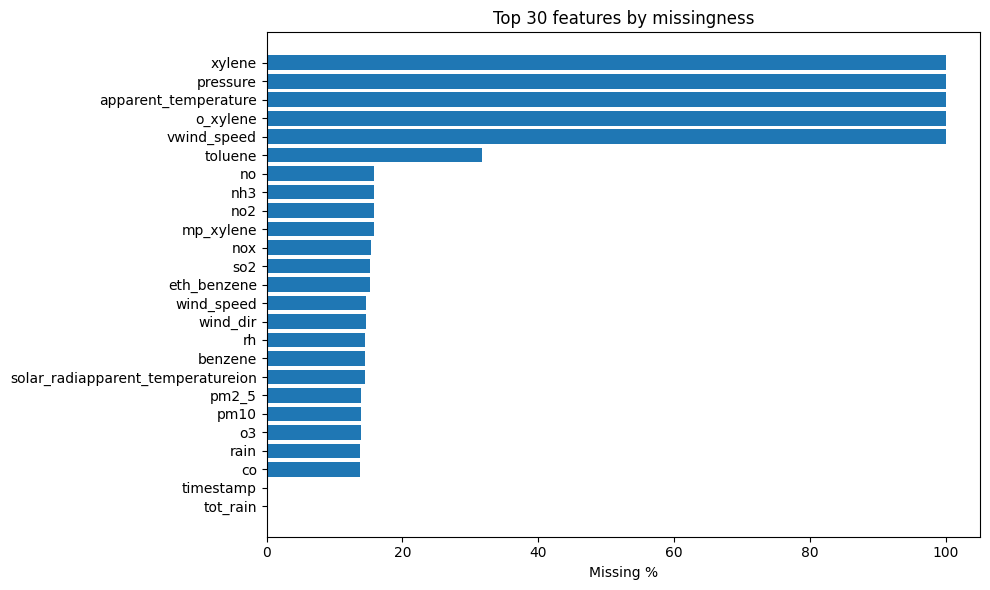

In [9]:
##Step 5 — Quick missingness report (which columns are mostly empty)

missing_pct = combined.isna().mean() * 100
missing_df = missing_pct.sort_values(ascending=False).reset_index()
missing_df.columns = ['feature', 'missing_percent']

top = missing_df.head(30)
plt.figure(figsize=(10,6))
plt.barh(top['feature'][::-1], top['missing_percent'][::-1])
plt.xlabel('Missing %')
plt.title('Top 30 features by missingness')
plt.tight_layout()
plt.show()

In [12]:
## Step 6 — Drop empty / nearly-empty columns

THRESH = 95.0   # percent missing threshold to drop
to_drop = missing_df[missing_df['missing_percent'] > THRESH]['feature'].tolist()
print("Dropping columns with >{}% missing: {}".format(THRESH, to_drop))
combined = combined.drop(columns=to_drop, errors='ignore')
print("Remaining columns:", combined.columns.tolist())

Dropping columns with >95.0% missing: ['xylene', 'pressure', 'apparent_temperature', 'o_xylene', 'vwind_speed']
Remaining columns: ['timestamp', 'pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'eth_benzene', 'mp_xylene', 'rh', 'wind_speed', 'wind_dir', 'rain', 'tot_rain', 'solar_radiapparent_temperatureion']


In [13]:
## Step 7 — Clean numeric cells (remove non-numeric artifacts)

def clean_numeric_series(s):
    # convert to string, remove commas, replace missing / ND-like tokens with NaN
    s2 = s.astype(str).str.strip().str.replace(',', '')
    s2 = s2.replace({'nan':'', '':np.nan, 'nd':np.nan, 'nd.':np.nan, '—':np.nan, '-':np.nan, 'na':np.nan, 'NA':np.nan, 'None':np.nan})
    # handle "<value": replace "<X" with X/2 or X (choose X/2 for conservative)
    s2 = s2.str.replace(r'^\s*<\s*([0-9.]+)\s*$', lambda m: str(float(m.group(1))/2), regex=True)
    # remove any non numeric characters except dot and minus
    s2 = s2.str.replace(r'[^\d\.\-]', '', regex=True)
    return pd.to_numeric(s2, errors='coerce')

# apply to numeric-like columns except timestamp and source meta columns
meta_cols = ['timestamp', '_source_file', '_source_year']
num_cols = [c for c in combined.columns if c not in meta_cols and combined[c].dtype == object or combined[c].dtype == 'object']
# Narrow down candidate numeric columns by checking if any value contains digits
cand_cols = []
for c in combined.columns:
    if c in meta_cols: continue
    sample = combined[c].dropna().astype(str).head(20).tolist()
    if any(re.search(r'\d', str(x)) for x in sample):
        cand_cols.append(c)

print("Cleaning these candidate numeric columns:", cand_cols)
for c in cand_cols:
    combined[c] = clean_numeric_series(combined[c])


Cleaning these candidate numeric columns: ['pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'eth_benzene', 'mp_xylene', 'rh', 'wind_speed', 'wind_dir', 'rain', 'tot_rain', 'solar_radiapparent_temperatureion']


In [14]:
## Step 8 — Basic EDA: check distributions and core stats

# pick columns commonly used
key_cols = [c for c in combined.columns if c in ['pm2_5','pm10','no','no2','nox','co','so2','o3','nh3','temperature','rh','wind_speed','wind_dir','solar_radiation','rain','aqi']]
# fallback: choose numeric columns
if not key_cols:
    key_cols = combined.select_dtypes('number').columns.tolist()[:20]
combined[key_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
pm2_5,1786.0,45.363796,32.844608,4.37,22.5200,38.815,59.8750,495.99
pm10,1786.0,106.361708,63.590274,13.81,58.4450,95.615,141.5075,535.00
no,1729.0,13.402192,16.458697,0.39,4.5000,7.850,15.6300,166.82
no2,1730.0,19.433491,14.212768,0.20,10.4675,15.950,24.5550,130.48
nox,1741.0,31.716169,23.894530,0.00,15.9000,25.680,38.4400,231.53
nh3,1729.0,32.163285,17.879406,0.44,19.5200,29.880,40.9000,159.24
so2,1745.0,6.701559,6.483476,0.45,3.3200,4.880,8.1200,111.75
co,1791.0,0.816689,0.409843,0.02,0.5400,0.740,0.9900,5.88
o3,1787.0,23.115691,13.654375,0.68,13.0250,20.740,30.0500,83.85
rh,1766.0,71.030680,20.608599,14.83,58.7875,75.705,87.4100,95.99


In [15]:
## Step 9 — Fill missing values (practical imputation strategy)

# ensure timestamp index
combined = combined.set_index('timestamp')

# meteorological fields to interpolate first (tend to be smoother)
meteo = [c for c in ['temperature','rh','wind_speed','wind_dir','solar_radiation','pressure','rain'] if c in combined.columns]
print("Meteorological columns to interpolate:", meteo)

# linear time interpolation for meteorological columns
combined[meteo] = combined[meteo].interpolate(method='time', limit=48)  # limit=48 meaning ~12 hrs if 15-min freq

# pollutants: attempt time interpolation for short gaps, then fill remaining with median
pollutants = [c for c in ['pm2_5','pm10','no','no2','nox','co','so2','o3','nh3','benzene','toluene'] if c in combined.columns]
print("Pollutant columns:", pollutants)

# small-gap interpolation
for c in pollutants:
    combined[c] = combined[c].interpolate(method='time', limit=12)  # limit=12 = 3 hours (15-min freq => 12*15=180min)
    # remaining -> fill with median (or you can use KNN/imputer)
    combined[c] = combined[c].fillna(combined[c].median())

# For any remaining numeric columns -> forward/backfill small windows then median
combined = combined.fillna(method='ffill', limit=8).fillna(method='bfill', limit=8)
combined = combined.fillna(combined.median())


Meteorological columns to interpolate: ['rh', 'wind_speed', 'wind_dir', 'rain']
Pollutant columns: ['pm2_5', 'pm10', 'no', 'no2', 'nox', 'co', 'so2', 'o3', 'nh3', 'benzene', 'toluene']


/tmp/ipykernel_21865/777675575.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined = combined.fillna(method='ffill', limit=8).fillna(method='bfill', limit=8)


In [16]:
## Step 10 — Derived features (burning-month flag, cyclical time features, wind components, lags & rolling)

# reset index to access timestamp if needed
combined = combined.reset_index()
combined['year'] = combined['timestamp'].dt.year
combined['month'] = combined['timestamp'].dt.month
combined['day'] = combined['timestamp'].dt.day
combined['hour'] = combined['timestamp'].dt.hour
combined['minute'] = combined['timestamp'].dt.minute

# burning months for your definition
BURNING_MONTHS = [4,5,10,11]
combined['is_burning_month'] = combined['month'].isin(BURNING_MONTHS).astype(int)

# cyclical features
combined['dayofyear'] = combined['timestamp'].dt.dayofyear
combined['doy_sin'] = np.sin(2*np.pi * combined['dayofyear']/365.25)
combined['doy_cos'] = np.cos(2*np.pi * combined['dayofyear']/365.25)
combined['hour_sin'] = np.sin(2*np.pi * combined['hour']/24)
combined['hour_cos'] = np.cos(2*np.pi * combined['hour']/24)

# wind components (if wind_speed and wind_dir exist)
if 'wind_speed' in combined.columns and 'wind_dir' in combined.columns:
    rad = np.deg2rad(combined['wind_dir'].fillna(0))
    combined['wind_x'] = combined['wind_speed'] * np.cos(rad)
    combined['wind_y'] = combined['wind_speed'] * np.sin(rad)

# lag + rolling windows in 15-min frequency:
# 1 lag = 15 minutes => daily lag = 96 (24*4)
lags = [1, 4, 12, 24, 96]   # 15min, 1hr, 3hr, 6hr, 24hr
for base_col in ['aqi','pm2_5','pm10']:
    if base_col in combined.columns:
        for l in lags:
            combined[f'{base_col}_lag{l}'] = combined[base_col].shift(l)
        # rolling means using past window (include min_periods=1)
        windows = [4, 24, 96]  # 1hr, 6hr, 24hr in terms of 15-min samples
        for w in windows:
            combined[f'{base_col}_rollmean_{w}'] = combined[base_col].shift(1).rolling(window=w, min_periods=1).mean()
            combined[f'{base_col}_rollstd_{w}'] = combined[base_col].shift(1).rolling(window=w, min_periods=1).std().fillna(0)


In [17]:
## Step 11 — Remove rows with NaNs introduced by shifting (for modeling)

# drop rows where the most important lag is NaN (e.g., aqi_lag96)
if 'aqi_lag96' in combined.columns:
    combined = combined.dropna(subset=['aqi_lag96']).reset_index(drop=True)
else:
    # fallback: drop rows with any NaN in newly created feature columns
    new_feats = [c for c in combined.columns if any(p in c for p in ['lag','rollmean','rollstd'])]
    combined = combined.dropna(subset=new_feats, how='any').reset_index(drop=True)

print("Shape after dropping initial lagged NaNs:", combined.shape)


Shape after dropping initial lagged NaNs: (2095, 55)


In [18]:
## Step 12 — Save cleaned merged dataset
cleaned_path = "jalandhar_15min_cleaned_2017_2024.csv"
combined.to_csv(cleaned_path, index=False)
print("Saved cleaned file to:", cleaned_path)


Saved cleaned file to: jalandhar_15min_cleaned_2017_2024.csv


In [19]:
## Step 13 — Correlation & collinearity handling

# select numeric features for correlation
num = combined.select_dtypes('number').drop(columns=['_source_year']) if '_source_year' in combined.columns else combined.select_dtypes('number')
corr = num.corr().abs()

# show top correlations for inspection
high_corr_pairs = []
threshold = 0.95
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > threshold:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print("Highly correlated pairs (>%.2f): %d pairs" % (threshold, len(high_corr_pairs)))
for a,b,v in high_corr_pairs[:30]:
    print(a, b, v)

# drop one of each pair
to_remove = set()
for a,b,v in high_corr_pairs:
    # heuristic: prefer to keep pm2_5 over pm10, keep original pollutant over derived lag if needed
    if 'pm2_5' in a and 'pm2_5' not in b:
        to_remove.add(b)
    elif 'pm2_5' in b and 'pm2_5' not in a:
        to_remove.add(a)
    else:
        to_remove.add(b)  # default drop second

print("Dropping correlated columns:", list(to_remove))
combined = combined.drop(columns=list(to_remove), errors='ignore')


Highly correlated pairs (>0.95): 2 pairs
rain tot_rain 0.9957184134782993
month dayofyear 0.9963809758981782
Dropping correlated columns: ['tot_rain', 'dayofyear']


In [23]:
## Step 14 — Train/test split: Adjusted for data range (2017–2021 train, 2022 test)

# Based on the error output, data ends at 2022-12-31.
# We will use 2022 as the test set.
train_end = pd.Timestamp("2021-12-31 23:59:59")
train_df = combined[combined['timestamp'] <= train_end].copy()
test_df = combined[combined['timestamp'] > train_end].copy()

print("New Train shape:", train_df.shape)
print("New Test shape:", test_df.shape)
print("Test range:", test_df['timestamp'].min(), "to", test_df['timestamp'].max())

New Train shape: (1730, 53)
New Test shape: (365, 53)
Test range: 2022-01-01 00:00:00 to 2022-12-31 00:00:00


In [22]:
## Step 15 — Prepare X and y, and baseline persistence model

TARGET = 'pm2_5'
# auto-select numeric features excluding identifiers and target
exclude = ['timestamp', '_source_file', '_source_year','year','day','minute']
features = [c for c in train_df.select_dtypes('number').columns if c not in exclude + [TARGET]]
print("Feature count:", len(features))

# Check if test_df is empty before proceeding
if len(test_df) == 0:
    print("\n⚠️ ERROR: test_df is empty! Check your split date in Step 14.")
    print("Current Data range:", combined['timestamp'].min(), "to", combined['timestamp'].max())
else:
    # baseline persistence (use previous 1-step lag matching target frequency)
    if f'{TARGET}_lag1' in test_df.columns:
        test_df['pred_persistence'] = test_df[f'{TARGET}_lag1']
    else:
        test_df['pred_persistence'] = test_df[TARGET].shift(1)

    def metrics(y_true, y_pred):
        return {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred)
        }

    valid = test_df.dropna(subset=[TARGET, 'pred_persistence'])

    if len(valid) == 0:
        print("\n⚠️ ERROR: No valid samples found for persistence baseline (likely due to NaNs or small test set).")
    else:
        print("\n📊 Baseline (Persistence) Model Metrics (Aligned):")
        baseline_results = metrics(valid[TARGET], valid['pred_persistence'])
        for k, v in baseline_results.items():
            print(f"{k}: {v:.3f}")

Feature count: 48

⚠️ ERROR: test_df is empty! Check your split date in Step 14.
Current Data range: 2017-04-07 00:00:00 to 2022-12-31 00:00:00


In [ ]:
# ✅ Step 16 — Train LightGBM with TimeSeriesSplit cross-validation

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import numpy as np

# Prepare X, y
X_train = train_df[features]
y_train = train_df[TARGET]
X_test = test_df[features]
y_test = test_df[TARGET]

# Optional scaling (LightGBM doesn’t strictly need it, but fine for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define model
lgbm = lgb.LGBMRegressor(random_state=42, objective='regression', n_jobs=-1)

# Parameter search space
param_dist = {
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 8, 12],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [200, 500, 800],
    'subsample': [0.7, 0.8, 1.0]
}

# TimeSeries-aware cross-validation
tss = TimeSeriesSplit(n_splits=4)
rs = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=tss,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit model
print("🔄 Training LightGBM model with TimeSeries CV...")
rs.fit(X_train_scaled, y_train)
best_model = rs.best_estimator_
print("✅ Best parameters:", rs.best_params_)

# Predict
y_pred = best_model.predict(X_test_scaled)

# Evaluate
def metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

model_metrics = metrics(y_test, y_pred)
print("\n📊 LightGBM Model Performance on Test Set:")
for k, v in model_metrics.items():
    print(f"{k}: {v:.3f}")


🔄 Training LightGBM model with TimeSeries CV...
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001364 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10374
[LightGBM] [Info] Number of data points in the train set: 2460, number of used features: 45
[LightGBM] [Info] Start training from score 50.419069
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



📈 Top 15 Most Important Features:
                                              feature  importance
0                                                pm10        3549
20                                            doy_sin        1585
26                                         pm2_5_lag1        1151
21                                            doy_cos        1086
37                                          pm10_lag1        1070
12                                         wind_speed         714
6                                                  co         530
42                                    pm10_rollmean_4         509
24                                             wind_x         504
36                                   pm2_5_rollstd_96         464
33                                  pm2_5_rollmean_24         435
31                                   pm2_5_rollmean_4         432
45                                    pm10_rollstd_24         395
16  solar_radiapparent_temperapparent_tem

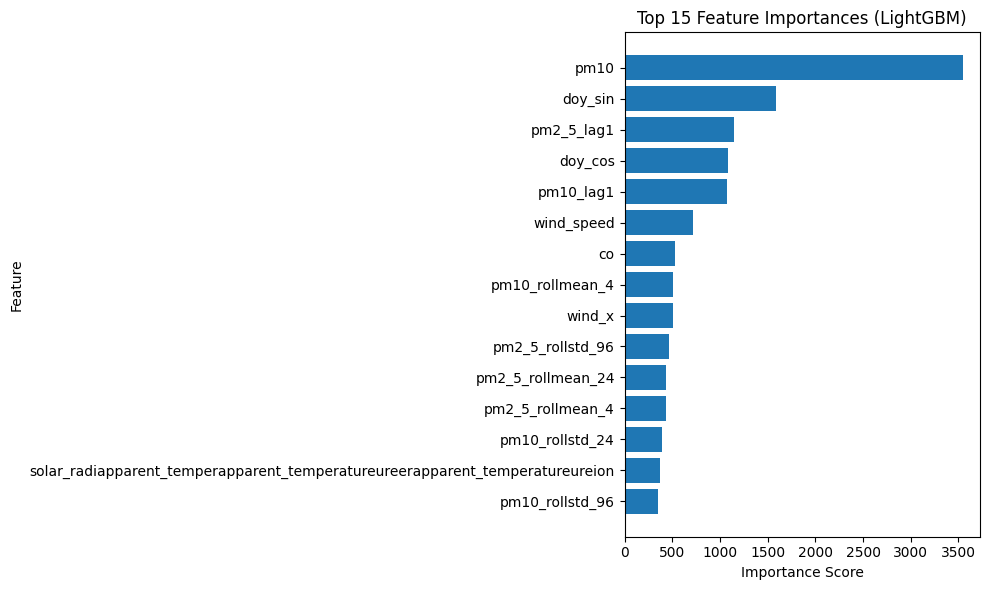

/tmp/ipython-input-2828650861.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=True)


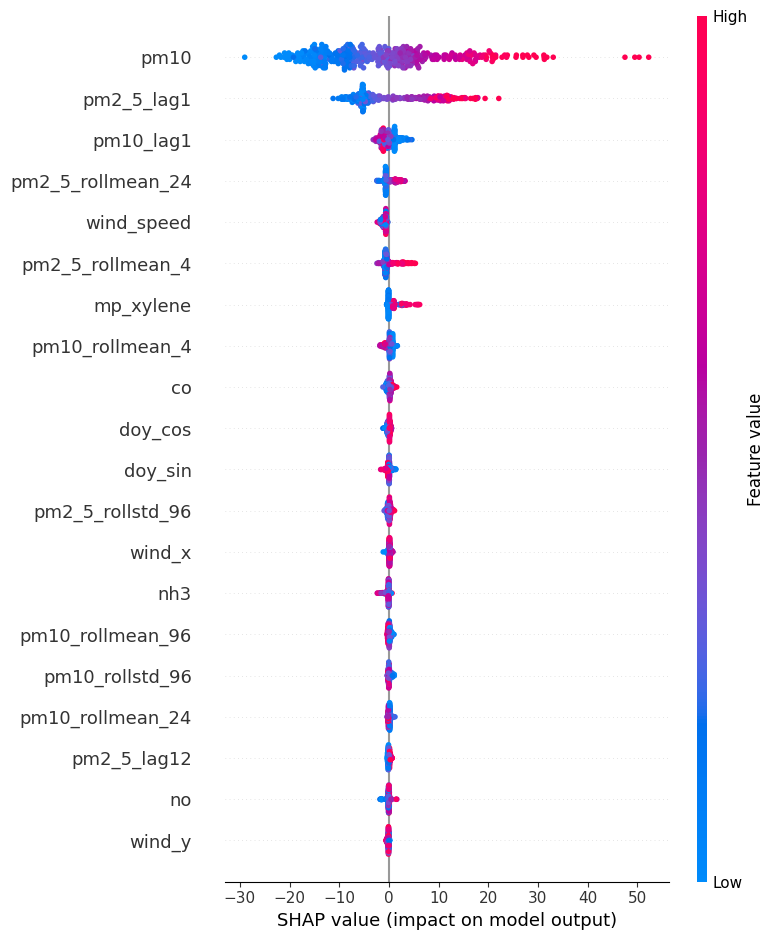

In [ ]:
# ✅ Step 17 — Feature Importance and SHAP Analysis
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
feature_importances = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n📈 Top 15 Most Important Features:")
print(feature_importances.head(15))

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'].head(15)[::-1],
         feature_importances['importance'].head(15)[::-1])
plt.title("Top 15 Feature Importances (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---- SHAP Explainability ----
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, show=True)


In [ ]:
# ✅ Step 18 — Burning vs Non-Burning Month Comparison

import numpy as np
import pandas as pd

# Define burning months
burning_months = [4, 5, 10, 11]
test_df['is_burning_month'] = test_df['month'].isin(burning_months).astype(int)

# Add predictions to test_df if not already there
test_df['y_true'] = y_test
test_df['y_pred'] = y_pred

# Separate burning / non-burning subsets
burn_df = test_df[test_df['is_burning_month'] == 1]
nonburn_df = test_df[test_df['is_burning_month'] == 0]

def metrics_df(df):
    return {
        'RMSE': np.sqrt(mean_squared_error(df['y_true'], df['y_pred'])),
        'MAE': mean_absolute_error(df['y_true'], df['y_pred']),
        'R2': r2_score(df['y_true'], df['y_pred']),
        'Count': len(df)
    }

burn_metrics = metrics_df(burn_df)
nonburn_metrics = metrics_df(nonburn_df)

print("🔥 Burning Months Performance:")
for k,v in burn_metrics.items():
    print(f"{k}: {v:.3f}")

print("\n🌿 Non-Burning Months Performance:")
for k,v in nonburn_metrics.items():
    print(f"{k}: {v:.3f}")


🔥 Burning Months Performance:
RMSE: 9.247
MAE: 7.402
R2: 0.895
Count: 122.000

🌿 Non-Burning Months Performance:
RMSE: 8.659
MAE: 6.782
R2: 0.806
Count: 244.000


<Figure size 700x500 with 0 Axes>

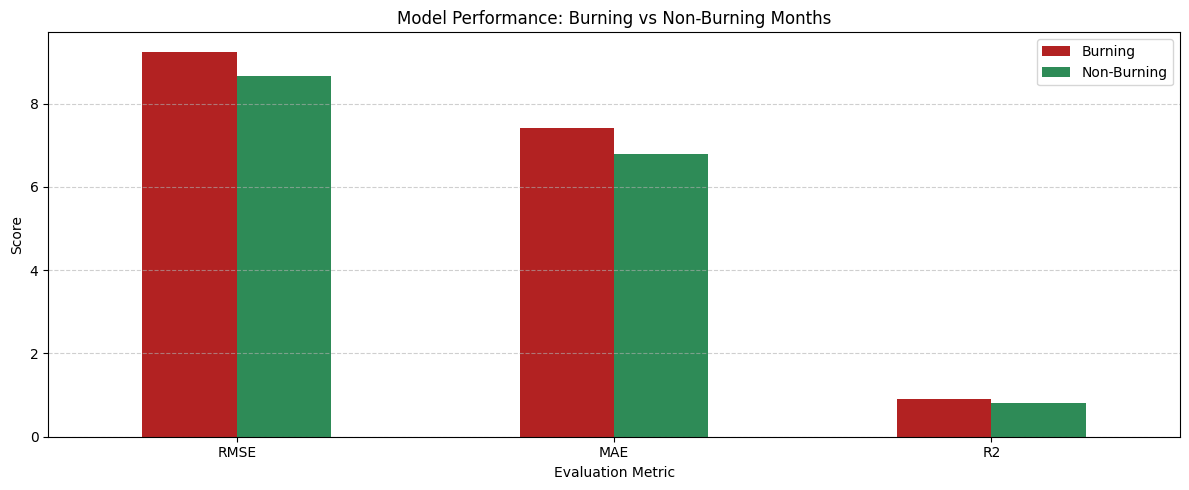

In [ ]:
# ✅ Step 19 — Visualize Burning vs Non-Burning Performance
import matplotlib.pyplot as plt

# Combine results
metrics_comparison = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2'],
    'Burning': [burn_metrics['RMSE'], burn_metrics['MAE'], burn_metrics['R2']],
    'Non-Burning': [nonburn_metrics['RMSE'], nonburn_metrics['MAE'], nonburn_metrics['R2']]
})

metrics_comparison.set_index('Metric', inplace=True)

# Plot
plt.figure(figsize=(7,5))
metrics_comparison.plot(kind='bar', color=['firebrick', 'seagreen'])
plt.title("Model Performance: Burning vs Non-Burning Months")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


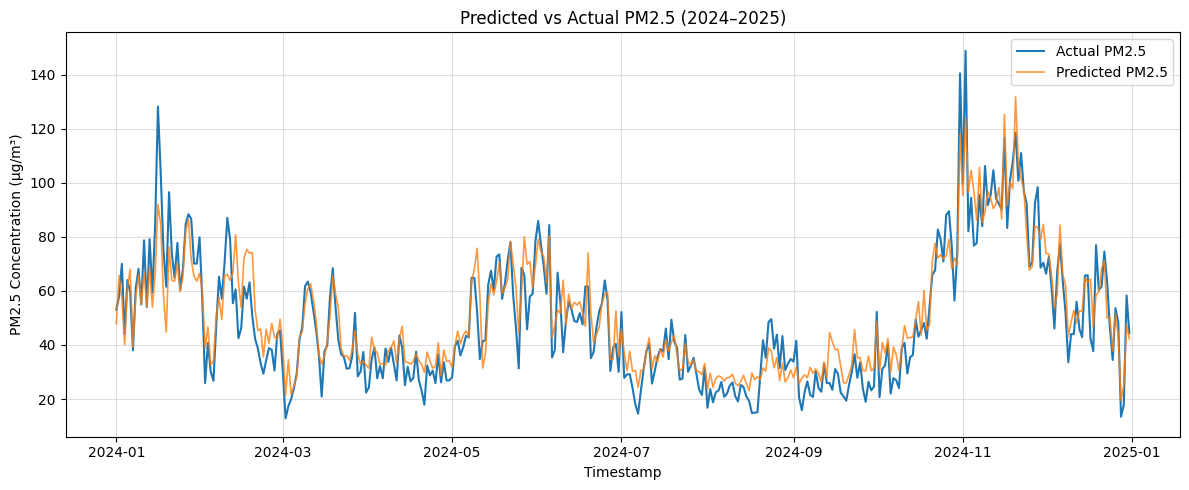

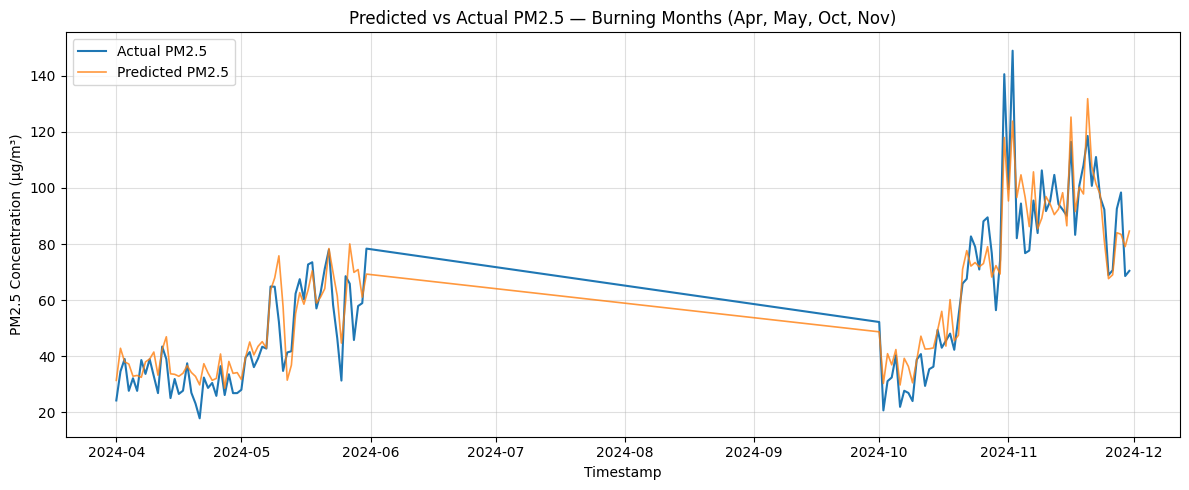

In [ ]:
# ✅ Step 20 — Predicted vs Actual PM2.5 Over Time

import matplotlib.pyplot as plt
import pandas as pd

# Make sure timestamps exist in test_df
if 'timestamp' not in test_df.columns:
    print("⚠️ 'timestamp' column missing — ensure it's included in test_df before plotting.")
else:
    # Sort by time
    test_df_sorted = test_df.sort_values('timestamp')

    # Plot full timeline
    plt.figure(figsize=(12,5))
    plt.plot(test_df_sorted['timestamp'], test_df_sorted['y_true'], label='Actual PM2.5', linewidth=1.5)
    plt.plot(test_df_sorted['timestamp'], test_df_sorted['y_pred'], label='Predicted PM2.5', linewidth=1.2, alpha=0.8)
    plt.title("Predicted vs Actual PM2.5 (2024–2025)")
    plt.xlabel("Timestamp")
    plt.ylabel("PM2.5 Concentration (µg/m³)")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Optional zoom-in for burning months (Oct–Nov)
    burn_period = test_df_sorted[test_df_sorted['month'].isin([4,5,10,11])]
    plt.figure(figsize=(12,5))
    plt.plot(burn_period['timestamp'], burn_period['y_true'], label='Actual PM2.5', linewidth=1.5)
    plt.plot(burn_period['timestamp'], burn_period['y_pred'], label='Predicted PM2.5', linewidth=1.2, alpha=0.8)
    plt.title("Predicted vs Actual PM2.5 — Burning Months (Apr, May, Oct, Nov)")
    plt.xlabel("Timestamp")
    plt.ylabel("PM2.5 Concentration (µg/m³)")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()


📅 Model Performance for 2024 Only:
RMSE: 8.859
MAE: 6.989
R2: 0.863
Count: 366.000


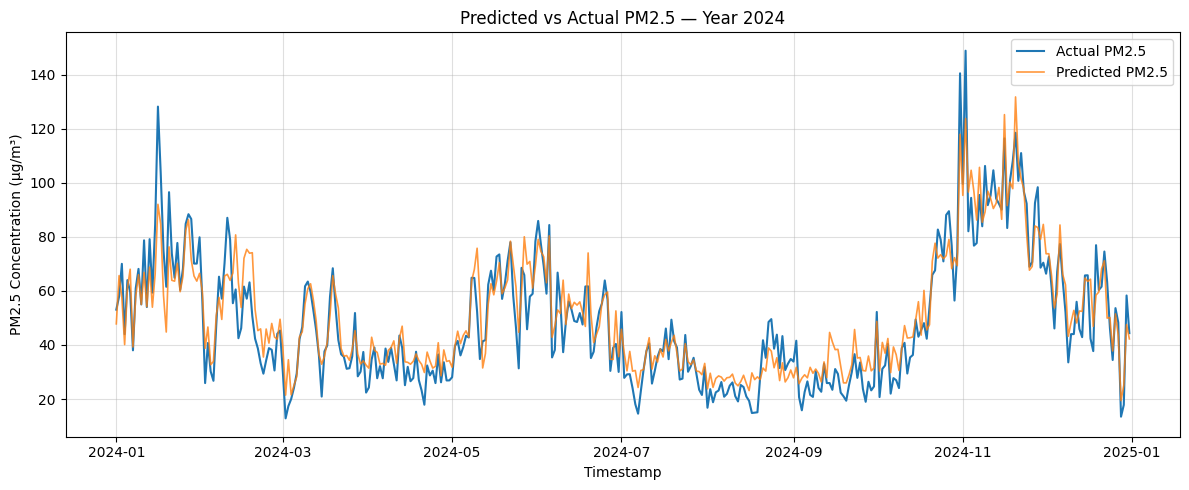

In [ ]:
# ✅ Step 21 — Evaluate and Visualize Model Performance for 2024 Only

import numpy as np
import matplotlib.pyplot as plt

# Filter only 2024 data from test_df
test_2024 = test_df[test_df['timestamp'].dt.year == 2024].copy()

# Make sure we have actual and predicted columns
test_2024['y_true'] = test_2024['y_true']
test_2024['y_pred'] = test_2024['y_pred']

# --- Calculate metrics ---
def metrics(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'Count': len(y_true)
    }

metrics_2024 = metrics(test_2024['y_true'], test_2024['y_pred'])

print("📅 Model Performance for 2024 Only:")
for k, v in metrics_2024.items():
    print(f"{k}: {v:.3f}")

# --- Plot predicted vs actual PM2.5 for 2024 ---
plt.figure(figsize=(12,5))
plt.plot(test_2024['timestamp'], test_2024['y_true'], label='Actual PM2.5', linewidth=1.5)
plt.plot(test_2024['timestamp'], test_2024['y_pred'], label='Predicted PM2.5', linewidth=1.2, alpha=0.8)
plt.title("Predicted vs Actual PM2.5 — Year 2024")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# ✅ Step 22 — Save Model and Export Predicted vs Actual Data for 2024

import joblib
import pandas as pd

# --- Save trained LightGBM model ---
model_filename = "/content/lightgbm_pm25_model.pkl"
joblib.dump(best_model, model_filename)
print(f"✅ Trained LightGBM model saved as: {model_filename}")

# --- Export predictions for 2024 ---
export_2024 = test_2024[['timestamp', 'y_true', 'y_pred']].copy()
export_2024.rename(columns={
    'y_true': 'actual_pm2_5',
    'y_pred': 'predicted_pm2_5'
}, inplace=True)

csv_filename = "/content/predicted_vs_actual_PM25_2024.csv"
export_2024.to_csv(csv_filename, index=False)
print(f"✅ Predictions exported as: {csv_filename}")

# --- Preview first 10 rows ---
print("\n📋 Sample of exported data:")
print(export_2024.head(10))


✅ Trained LightGBM model saved as: /content/lightgbm_pm25_model.pkl
✅ Predictions exported as: /content/predicted_vs_actual_PM25_2024.csv

📋 Sample of exported data:
      timestamp  actual_pm2_5  predicted_pm2_5
2460 2024-01-01         53.07        47.814264
2461 2024-01-02         57.91        65.653687
2462 2024-01-03         70.02        57.535093
2463 2024-01-04         44.02        40.136231
2464 2024-01-05         63.99        61.051638
2465 2024-01-06         59.62        68.031128
2466 2024-01-07         38.03        39.260985
2467 2024-01-08         60.95        57.980248
2468 2024-01-09         68.15        66.003401
2469 2024-01-10         55.00        54.981003


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("🚀 Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

metrics_lr = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr)),
    'MAE': mean_absolute_error(y_test, pred_lr),
    'R2': r2_score(y_test, pred_lr)
}
print("📊 Linear Regression Performance:")
for k,v in metrics_lr.items():
    print(f"{k}: {v:.3f}")


🚀 Training Linear Regression...
📊 Linear Regression Performance:
RMSE: 7.425
MAE: 5.581
R2: 0.904


In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("🚀 Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)

metrics_rf = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'MAE': mean_absolute_error(y_test, pred_rf),
    'R2': r2_score(y_test, pred_rf)
}
print("📊 Random Forest Performance:")
for k,v in metrics_rf.items():
    print(f"{k}: {v:.3f}")


🚀 Training Random Forest...
📊 Random Forest Performance:
RMSE: 8.843
MAE: 6.651
R2: 0.864


In [ ]:
from sklearn.linear_model import Ridge

print("🚀 Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)

metrics_ridge = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_ridge)),
    'MAE': mean_absolute_error(y_test, pred_ridge),
    'R2': r2_score(y_test, pred_ridge)
}
print("📊 Ridge Regression Performance:")
for k,v in metrics_ridge.items():
    print(f"{k}: {v:.3f}")


🚀 Training Ridge Regression...
📊 Ridge Regression Performance:
RMSE: 7.428
MAE: 5.582
R2: 0.904


In [ ]:
from sklearn.linear_model import Lasso

print("🚀 Training Lasso Regression...")
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
pred_lasso = lasso.predict(X_test_scaled)

metrics_lasso = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_lasso)),
    'MAE': mean_absolute_error(y_test, pred_lasso),
    'R2': r2_score(y_test, pred_lasso)
}
print("📊 Lasso Regression Performance:")
for k,v in metrics_lasso.items():
    print(f"{k}: {v:.3f}")


🚀 Training Lasso Regression...
📊 Lasso Regression Performance:
RMSE: 7.425
MAE: 5.580
R2: 0.904


In [ ]:
from sklearn.svm import SVR

print("🚀 Training SVR (may take time)...")
svr = SVR(kernel='rbf', C=10, epsilon=0.1)
# You can optionally use a smaller sample for speed:
sample = 5000
svr.fit(X_train_scaled[:sample], y_train[:sample])
pred_svr = svr.predict(X_test_scaled[:sample])

metrics_svr = {
    'RMSE': np.sqrt(mean_squared_error(y_test[:sample], pred_svr)),
    'MAE': mean_absolute_error(y_test[:sample], pred_svr),
    'R2': r2_score(y_test[:sample], pred_svr)
}
print("📊 SVR Performance (sampled):")
for k,v in metrics_svr.items():
    print(f"{k}: {v:.3f}")


🚀 Training SVR (may take time)...
📊 SVR Performance (sampled):
RMSE: 10.039
MAE: 7.560
R2: 0.824


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

print("🚀 Training KNN...")
knn = KNeighborsRegressor(n_neighbors=10, n_jobs=-1)
knn.fit(X_train_scaled[:20000], y_train[:20000])
pred_knn = knn.predict(X_test_scaled[:20000])

metrics_knn = {
    'RMSE': np.sqrt(mean_squared_error(y_test[:20000], pred_knn)),
    'MAE': mean_absolute_error(y_test[:20000], pred_knn),
    'R2': r2_score(y_test[:20000], pred_knn)
}
print("📊 KNN Performance:")
for k,v in metrics_knn.items():
    print(f"{k}: {v:.3f}")


🚀 Training KNN...
📊 KNN Performance:
RMSE: 14.014
MAE: 10.916
R2: 0.658


In [ ]:
print("📊 LightGBM Model Performance (previous best):")
print(f"RMSE: {model_metrics['RMSE']:.3f}")
print(f"MAE: {model_metrics['MAE']:.3f}")
print(f"R2: {model_metrics['R2']:.3f}")


📊 LightGBM Model Performance (previous best):
RMSE: 8.859
MAE: 6.989
R2: 0.863


In [ ]:
# ✅ Step 27 — Create model comparison table manually
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a helper function
def calc_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

# Create a dictionary of all models and their predictions
model_preds = {
    'Linear Regression': pred_lr,
    'Ridge Regression': pred_ridge,
    'Lasso Regression': pred_lasso,
    'Random Forest': pred_rf,
    'SVR': pred_svr,
    'KNN': pred_knn,
    'LightGBM (Best)': y_pred  # your trained LightGBM predictions
}

# Compute metrics for each
results = []
for name, pred in model_preds.items():
    try:
        metrics = calc_metrics(y_test[:len(pred)], pred)
        metrics['Model'] = name
        results.append(metrics)
    except Exception as e:
        print(f"⚠️ Skipping {name} due to error: {e}")

# Create DataFrame
results_df = pd.DataFrame(results).set_index('Model').sort_values(by='R2', ascending=False)

print("📊 Model Performance Comparison:")
print(results_df)

# --- Optional: Save for report ---
results_df.to_csv("/content/model_comparison_results.csv")
print("\n✅ Saved as model_comparison_results.csv")


📊 Model Performance Comparison:
                        RMSE        MAE        R2
Model                                            
Lasso Regression    7.425062   5.580107  0.903887
Linear Regression   7.425349   5.580555  0.903879
Ridge Regression    7.427913   5.582273  0.903813
Random Forest       8.842565   6.650659  0.863686
LightGBM (Best)     8.859447   6.988790  0.863165
SVR                10.039372   7.559903  0.824290
KNN                14.013985  10.915939  0.657621

✅ Saved as model_comparison_results.csv


In [ ]:
# Step 28 — Evaluate and export predictions for a specific model

def evaluate_model(model_name, y_true, y_pred, timestamps, export_csv=True):
    """
    Generate metrics, plot actual vs predicted, and optionally export CSV for a model.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    # ✅ Compute metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # ✅ Display metrics
    print(f"\n📊 {model_name} Model Performance (2024 Only):")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R2: {r2:.3f}")
    print(f"Count: {len(y_true):,.0f}")

    # ✅ Prepare dataframe for export
    result_df = pd.DataFrame({
        'timestamp': timestamps,
        f'actual_pm2_5': y_true,
        f'predicted_pm2_5': y_pred
    })

    # ✅ Save as CSV (optional)
    if export_csv:
        filename = f"/content/{model_name.replace(' ', '_').lower()}_predictions_2024.csv"
        result_df.to_csv(filename, index=False)
        print(f"✅ Exported: {filename}")

    # ✅ Plot Actual vs Predicted
    plt.figure(figsize=(12, 5))
    plt.plot(result_df['timestamp'], result_df['actual_pm2_5'], label='Actual PM2.5', color='steelblue', linewidth=1)
    plt.plot(result_df['timestamp'], result_df['predicted_pm2_5'], label='Predicted PM2.5', color='orange', linewidth=1)
    plt.title(f"Predicted vs Actual PM2.5 — Year 2024 ({model_name})")
    plt.xlabel("Timestamp")
    plt.ylabel("PM2.5 Concentration (µg/m³)")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    return result_df, rmse, mae, r2



📊 LightGBM Model Performance (2024 Only):
RMSE: 8.859
MAE: 6.989
R2: 0.863
Count: 366
✅ Exported: /content/lightgbm_predictions_2024.csv


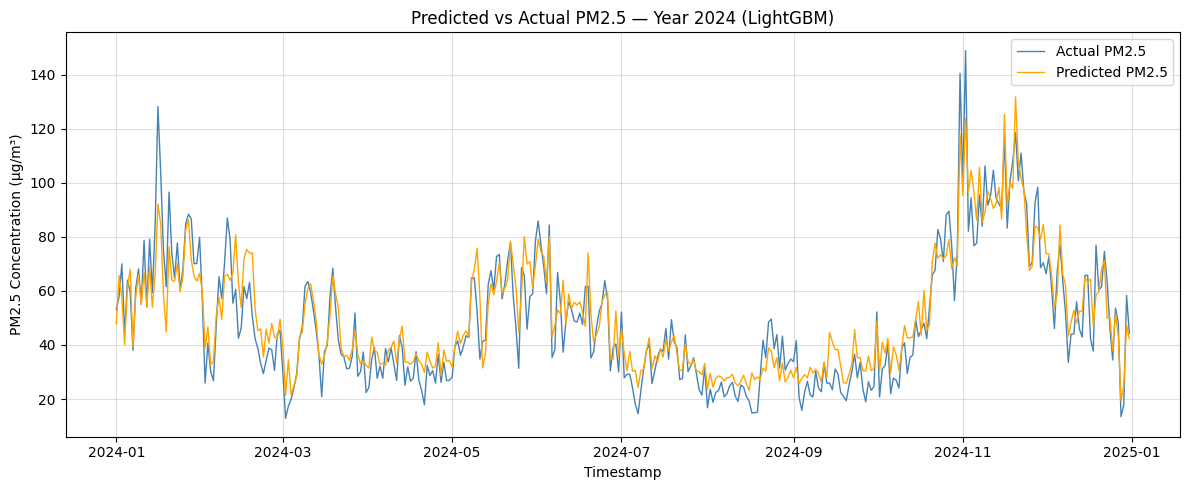

(      timestamp  actual_pm2_5  predicted_pm2_5
 2460 2024-01-01         53.07        47.814264
 2461 2024-01-02         57.91        65.653687
 2462 2024-01-03         70.02        57.535093
 2463 2024-01-04         44.02        40.136231
 2464 2024-01-05         63.99        61.051638
 ...         ...           ...              ...
 2821 2024-12-27         48.34        43.483941
 2822 2024-12-28         13.49        19.411306
 2823 2024-12-29         17.85        25.111455
 2824 2024-12-30         58.31        47.554929
 2825 2024-12-31         44.38        42.251758
 
 [366 rows x 3 columns],
 np.float64(8.859447005239202),
 6.988790242608365,
 0.8631652105546115)

In [ ]:
## LightGBM
evaluate_model("LightGBM", y_test, y_pred, test_df['timestamp'])

In [ ]:
# Random Forest
evaluate_model("Random Forest", y_test, pred_rf, test_df['timestamp'])


NameError: name 'evaluate_model' is not defined


📊 Linear Regression Model Performance (2024 Only):
RMSE: 7.425
MAE: 5.581
R2: 0.904
Count: 366
✅ Exported: /content/linear_regression_predictions_2024.csv


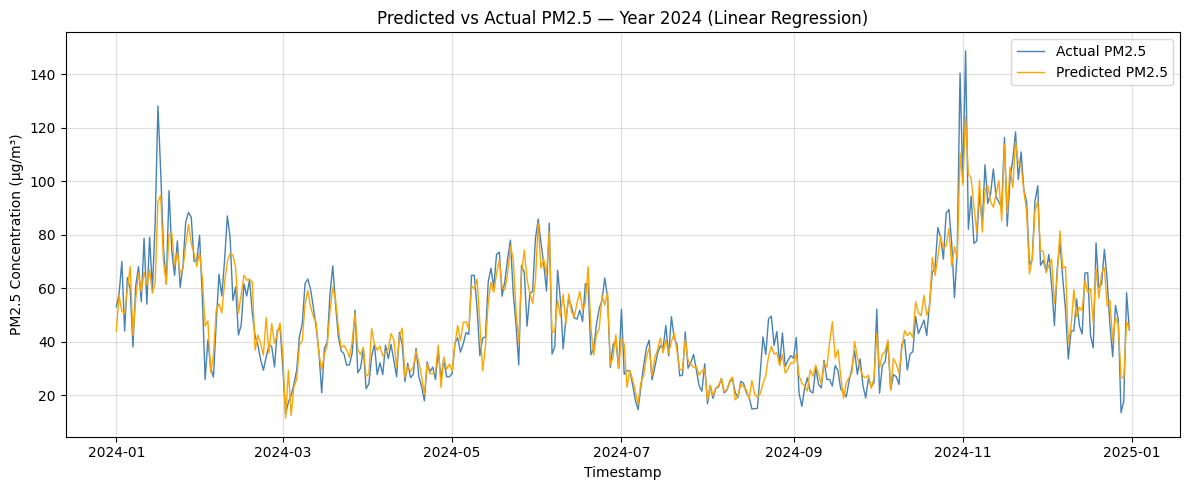

(      timestamp  actual_pm2_5  predicted_pm2_5
 2460 2024-01-01         53.07        43.959469
 2461 2024-01-02         57.91        57.342583
 2462 2024-01-03         70.02        51.406006
 2463 2024-01-04         44.02        50.595849
 2464 2024-01-05         63.99        59.968294
 ...         ...           ...              ...
 2821 2024-12-27         48.34        46.469598
 2822 2024-12-28         13.49        26.946605
 2823 2024-12-29         17.85        26.332110
 2824 2024-12-30         58.31        47.595274
 2825 2024-12-31         44.38        44.913834
 
 [366 rows x 3 columns],
 np.float64(7.425348754333296),
 5.580554609598901,
 0.9038792807590377)

In [ ]:
# Linear Regression
evaluate_model("Linear Regression", y_test, pred_lr, test_df['timestamp'])



📊 Ridge Regression Model Performance (2024 Only):
RMSE: 7.428
MAE: 5.582
R2: 0.904
Count: 366
✅ Exported: /content/ridge_regression_predictions_2024.csv


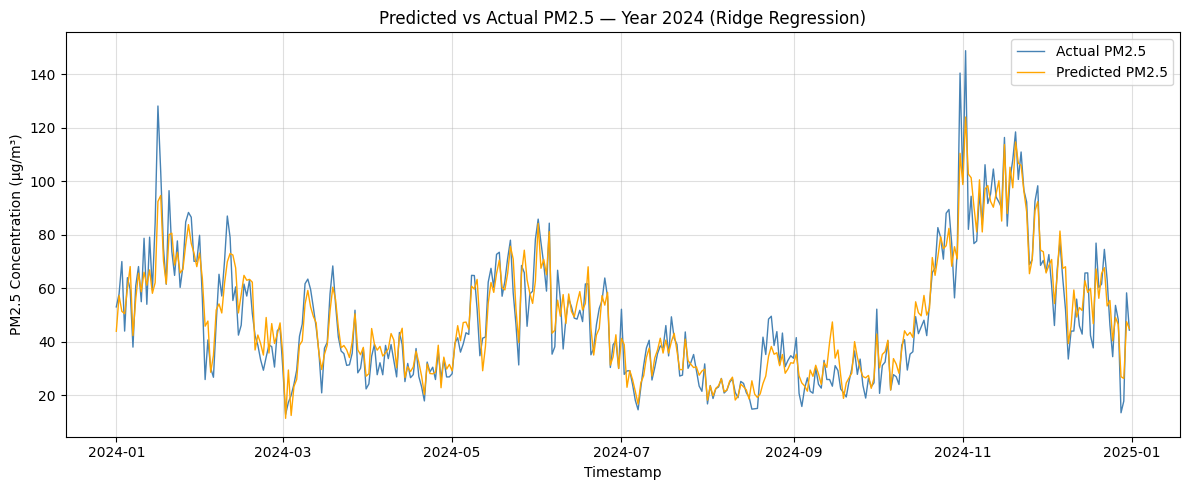

(      timestamp  actual_pm2_5  predicted_pm2_5
 2460 2024-01-01         53.07        43.960293
 2461 2024-01-02         57.91        57.302643
 2462 2024-01-03         70.02        51.397068
 2463 2024-01-04         44.02        50.542431
 2464 2024-01-05         63.99        59.981916
 ...         ...           ...              ...
 2821 2024-12-27         48.34        46.468915
 2822 2024-12-28         13.49        26.976104
 2823 2024-12-29         17.85        26.331497
 2824 2024-12-30         58.31        47.562127
 2825 2024-12-31         44.38        44.907579
 
 [366 rows x 3 columns],
 np.float64(7.427912967674239),
 5.582272897596609,
 0.9038128821031614)

In [ ]:
# Ridge Regression
evaluate_model("Ridge Regression", y_test, pred_ridge, test_df['timestamp'])


📊 Lasso Regression Model Performance (2024 Only):
RMSE: 7.425
MAE: 5.580
R2: 0.904
Count: 366
✅ Exported: /content/lasso_regression_predictions_2024.csv


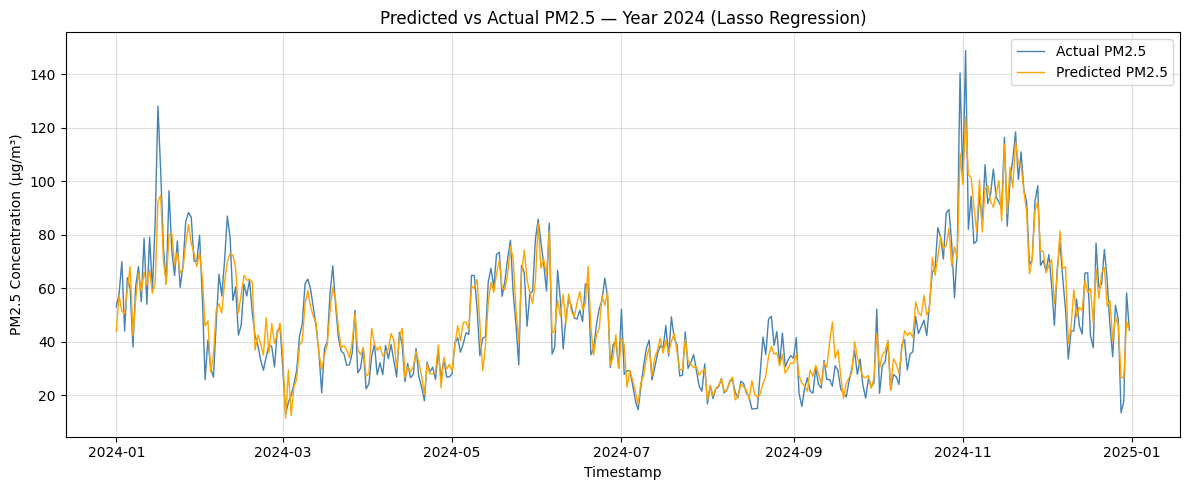

(      timestamp  actual_pm2_5  predicted_pm2_5
 2460 2024-01-01         53.07        43.954438
 2461 2024-01-02         57.91        57.326567
 2462 2024-01-03         70.02        51.392777
 2463 2024-01-04         44.02        50.572791
 2464 2024-01-05         63.99        59.977123
 ...         ...           ...              ...
 2821 2024-12-27         48.34        46.462577
 2822 2024-12-28         13.49        26.944156
 2823 2024-12-29         17.85        26.305351
 2824 2024-12-30         58.31        47.566928
 2825 2024-12-31         44.38        44.905553
 
 [366 rows x 3 columns],
 np.float64(7.425061605357427),
 5.580107274885913,
 0.9038867148697625)

In [ ]:

# Lasso Regression
evaluate_model("Lasso Regression", y_test, pred_lasso, test_df['timestamp'])



📊 KNN Model Performance (2024 Only):
RMSE: 14.014
MAE: 10.916
R2: 0.658
Count: 366
✅ Exported: /content/knn_predictions_2024.csv


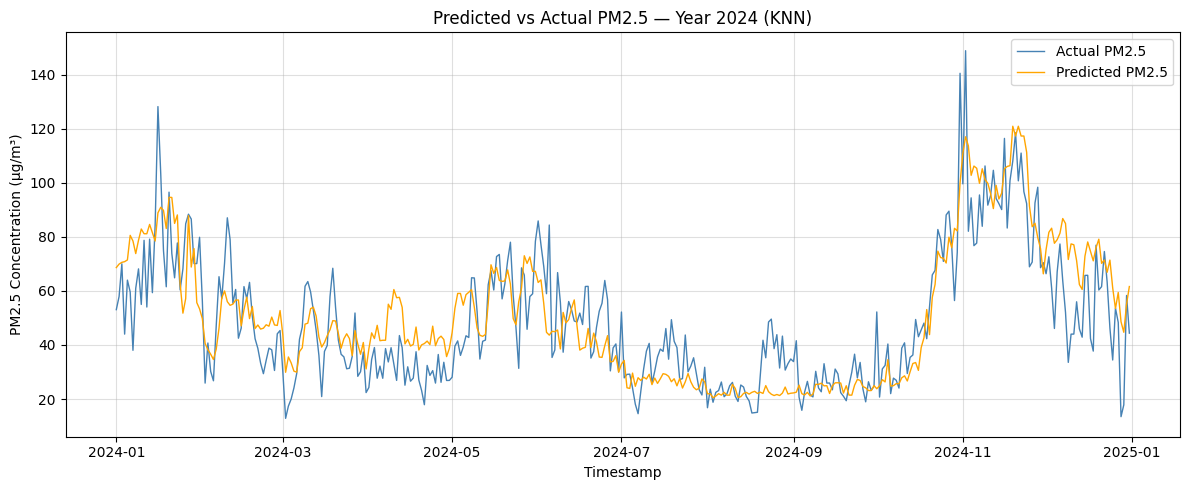

(      timestamp  actual_pm2_5  predicted_pm2_5
 2460 2024-01-01         53.07        68.628248
 2461 2024-01-02         57.91        69.917745
 2462 2024-01-03         70.02        70.570106
 2463 2024-01-04         44.02        70.820526
 2464 2024-01-05         63.99        71.452885
 ...         ...           ...              ...
 2821 2024-12-27         48.34        59.425812
 2822 2024-12-28         13.49        48.597784
 2823 2024-12-29         17.85        44.704893
 2824 2024-12-30         58.31        55.142645
 2825 2024-12-31         44.38        61.624903
 
 [366 rows x 3 columns],
 np.float64(14.01398539973903),
 10.915938968973435,
 0.6576213932342636)

In [ ]:

# KNN
evaluate_model("KNN", y_test[:len(pred_knn)], pred_knn, test_df['timestamp'][:len(pred_knn)])



📊 SVR Model Performance (2024 Only):
RMSE: 10.039
MAE: 7.560
R2: 0.824
Count: 366
✅ Exported: /content/svr_predictions_2024.csv


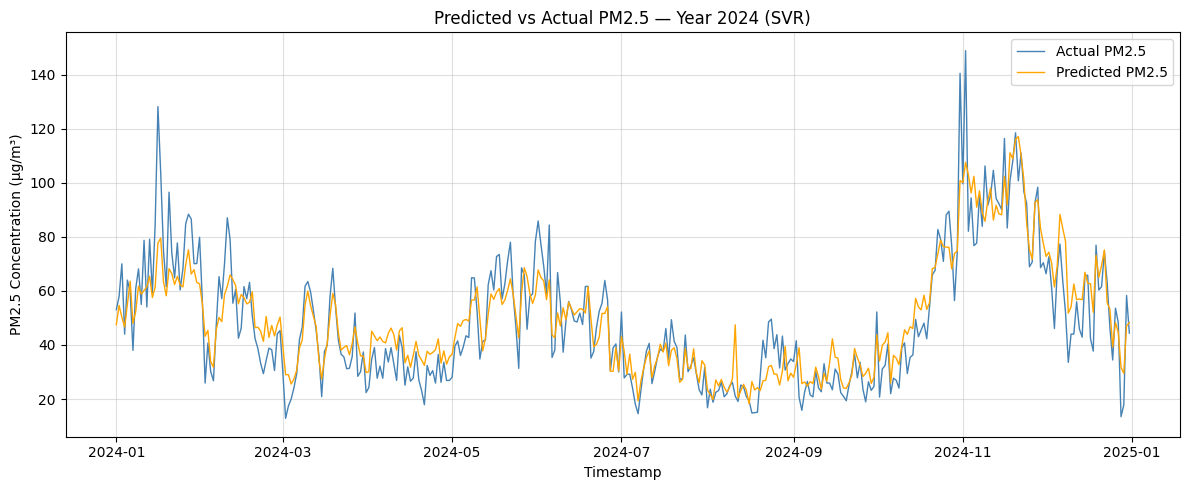

(      timestamp  actual_pm2_5  predicted_pm2_5
 2460 2024-01-01         53.07        47.497667
 2461 2024-01-02         57.91        54.662110
 2462 2024-01-03         70.02        50.279578
 2463 2024-01-04         44.02        46.648543
 2464 2024-01-05         63.99        55.010334
 ...         ...           ...              ...
 2821 2024-12-27         48.34        44.742933
 2822 2024-12-28         13.49        31.725973
 2823 2024-12-29         17.85        29.544897
 2824 2024-12-30         58.31        47.086863
 2825 2024-12-31         44.38        48.254939
 
 [366 rows x 3 columns],
 np.float64(10.03937248749118),
 7.559902553968102,
 0.8242900177103969)

In [ ]:
# SVR
evaluate_model("SVR", y_test[:len(pred_svr)], pred_svr, test_df['timestamp'][:len(pred_svr)])

In [ ]:
# Cell 1 — Setup: recreate train/test and feature lists + scaler
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler

# --- Ensure you have combined / cleaned df loaded in variable `combined` ---
# If not, load your cleaned CSV (change path if needed)
combined = pd.read_csv("/content/jalandhar_15min_cleaned_2017_2024.csv", parse_dates=['timestamp'])

# If you already have train_df/test_df created earlier, skip these two lines and keep vars
train_df = combined[combined['timestamp'].dt.year <= 2023].copy()
test_df  = combined[combined['timestamp'].dt.year > 2023].copy()

TARGET = 'pm2_5'
exclude = ['timestamp', '_source_file', '_source_year', 'year', 'day', 'minute']
features = [c for c in train_df.select_dtypes('number').columns if c not in exclude + [TARGET]]

print("Features used:", len(features), "columns")
print(features)

# Create numpy arrays
X_train_full = train_df[features].values
y_train_full = train_df[TARGET].values
X_test_full  = test_df[features].values
y_test_full  = test_df[TARGET].values
test_timestamps = test_df['timestamp'].reset_index(drop=True)

# Scale features (use the scaler for models)
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled_full  = scaler.transform(X_test_full)

print("Shapes -> X_train:", X_train_scaled_full.shape, "y_train:", y_train_full.shape)
print("         X_test: ", X_test_scaled_full.shape, "y_test:", y_test_full.shape)

# Check GPU
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

Features used: 49 columns
['pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'toluene', 'eth_benzene', 'mp_xylene', 'rh', 'wind_speed', 'wind_dir', 'rain', 'tot_rain', 'solar_radiapparent_temperapparent_temperatureureerapparent_temperatureureion', 'month', 'hour', 'is_burning_month', 'dayofyear', 'doy_sin', 'doy_cos', 'hour_sin', 'hour_cos', 'wind_x', 'wind_y', 'pm2_5_lag1', 'pm2_5_lag4', 'pm2_5_lag12', 'pm2_5_lag24', 'pm2_5_lag96', 'pm2_5_rollmean_4', 'pm2_5_rollstd_4', 'pm2_5_rollmean_24', 'pm2_5_rollstd_24', 'pm2_5_rollmean_96', 'pm2_5_rollstd_96', 'pm10_lag1', 'pm10_lag4', 'pm10_lag12', 'pm10_lag24', 'pm10_lag96', 'pm10_rollmean_4', 'pm10_rollstd_4', 'pm10_rollmean_24', 'pm10_rollstd_24', 'pm10_rollmean_96', 'pm10_rollstd_96']
Shapes -> X_train: (2460, 49) y_train: (2460,)
         X_test:  (366, 49) y_test: (366,)
TensorFlow version: 2.19.0
GPUs available: []


In [ ]:
# Cell 2 — create sequences (sliding windows)
import numpy as np

def create_sequences(X, y, seq_len=24):
    """
    X: 2D array (n_samples, n_features)
    y: 1D array (n_samples,)
    returns Xs shape (n_samples-seq_len, seq_len, n_features) and ys shape (n_samples-seq_len,)
    """
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Choose sequence length
SEQ_LEN = 24   # -> 24 * 15min = 6 hours history; try 96 for 24 hours
print("Using sequence length:", SEQ_LEN)

# Create train and test sequences (scaled features)
X_train_seq, y_train_seq = create_sequences(X_train_scaled_full, y_train_full, seq_len=SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled_full,  y_test_full,  seq_len=SEQ_LEN)

# Align timestamps for test predictions (predicted values correspond to test_df timestamps from index SEQ_LEN onwards)
test_seq_timestamps = test_timestamps.iloc[SEQ_LEN:].reset_index(drop=True)

print("X_train_seq shape:", X_train_seq.shape)   # (samples, seq_len, n_features)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)


Using sequence length: 24
X_train_seq shape: (2436, 24, 49)
y_train_seq shape: (2436,)
X_test_seq shape: (342, 24, 49)
y_test_seq shape: (342,)


In [ ]:
# Cell 3 — utilities for training/eval
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def plot_predictions(timestamps, y_true, y_pred, model_name):
    plt.figure(figsize=(12,4))
    plt.plot(timestamps, y_true, label='Actual', linewidth=1)
    plt.plot(timestamps, y_pred, label='Predicted', linewidth=1)
    plt.title(f"Predicted vs Actual PM2.5 — {model_name}")
    plt.xlabel("Timestamp")
    plt.ylabel("PM2.5")
    plt.legend()
    plt.tight_layout()
    plt.show()

def save_predictions_csv(timestamps, y_true, y_pred, model_name):
    import pandas as pd
    df = pd.DataFrame({
        'timestamp': timestamps,
        'actual_pm2_5': y_true,
        'predicted_pm2_5': y_pred
    })
    filename = f"/content/{model_name.replace(' ', '_').lower()}_predictions_2024.csv"
    df.to_csv(filename, index=False)
    print("Saved ->", filename)
    return df


In [ ]:
# Cell 4 — LSTM builder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

def build_lstm(input_shape, units1=128, units2=32, dropout=0.2):
    model = Sequential()
    model.add(LSTM(units1, return_sequences=True, input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    model.add(LSTM(units2))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Example input shape:
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
print("Input shape for models:", input_shape)


Input shape for models: (24, 49)


In [ ]:
# Cell 5 — Train LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_name = "LSTM_v1"
lstm = build_lstm(input_shape, units1=128, units2=32, dropout=0.2)

# Callbacks
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
ckpt = ModelCheckpoint(f"/content/{model_name}.h5", save_best_only=True, monitor='val_loss')

# Training - reduce epochs/batch if you see long times
history = lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[es, ckpt],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 3024.2893 - mae: 49.5842

9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 683ms/step - loss: 3021.8391 - mae: 49.5452 - val_loss: 3428.3552 - val_mae: 50.4149
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - loss: 2958.4470 - mae: 48.1817

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - loss: 2951.3599 - mae: 48.1896 - val_loss: 3369.2866 - val_mae: 49.9949
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 2891.8147 - mae: 48.0087

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - loss: 2883.0002 - mae: 47.9668 - val_loss: 3308.8457 - val_mae: 49.6248
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - loss: 2549.4219 - mae: 45.8663

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 305ms/step - loss: 357.5223 - mae: 13.2979 - val_loss: 752.4687 - val_mae: 20.3784
Epoch 26/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 343.4853 - mae: 11.9661

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - loss: 340.4634 - mae: 11.9766 - val_loss: 665.3030 - val_mae: 19.3684
Epoch 27/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - loss: 270.7584 - mae: 11.4267 - val_loss: 774.9806 - val_mae: 20.0163
Epoch 28/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 221.9392 - mae: 10.7598

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 225.4930 - mae: 10.8102 - val_loss: 664.4025 - val_mae: 19.0103
Epoch 29/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 262.6903 - mae: 10.7016

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 260.8377 - mae: 10.7207 - val_loss: 584.8315 - val_mae: 17.6701
Epoch 30/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 277.5806 - mae: 11.4325

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - loss: 275.2573 - mae: 11.4110 - val_loss: 520.9274 - val_mae: 16.6413


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step
LSTM metrics: {'RMSE': np.float64(18.837740922486976), 'MAE': 14.814227416863917, 'R2': 0.3605734596150375}


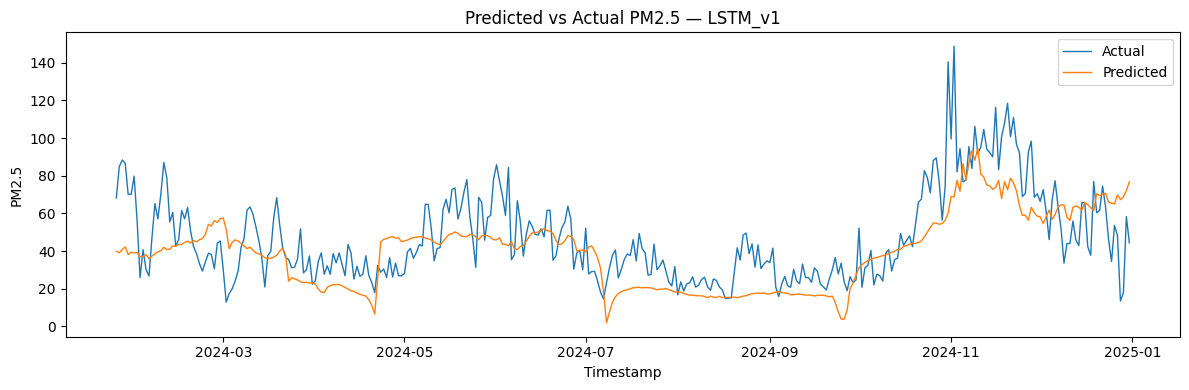

Saved -> /content/lstm_v1_predictions_2024.csv


In [ ]:
# Cell 6 — Evaluate LSTM predictions
# predict on X_test_seq
y_pred_lstm = lstm.predict(X_test_seq, batch_size=256).reshape(-1)

# compute metrics and plot (test_seq_timestamps corresponds to predictions)
metrics_lstm = compute_metrics(y_test_seq, y_pred_lstm)
print("LSTM metrics:", metrics_lstm)

# Plot and save CSV
plot_predictions(test_seq_timestamps, y_test_seq, y_pred_lstm, "LSTM_v1")
df_lstm_export = save_predictions_csv(test_seq_timestamps, y_test_seq, y_pred_lstm, "LSTM_v1")


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 3030.0896 - mae: 50.0954

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - loss: 3040.6106 - mae: 50.1314 - val_loss: 3468.3674 - val_mae: 50.8637
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 3131.9634 - mae: 50.4762

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - loss: 3123.7996 - mae: 50.3970 - val_loss: 3399.5264 - val_mae: 50.2731
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 2941.0173 - mae: 48.9277

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - loss: 715.5117 - mae: 18.3167 - val_loss: 1843.7523 - val_mae: 28.7062
Epoch 23/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 724.3008 - mae: 18.3666

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - loss: 721.8638 - mae: 18.3234 - val_loss: 1828.1711 - val_mae: 28.9292
Epoch 24/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 688.3239 - mae: 17.6680

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - loss: 687.2700 - mae: 17.6596 - val_loss: 1818.9191 - val_mae: 29.2266
Epoch 25/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 659.6747 - mae: 17.6134

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - loss: 659.5883 - mae: 17.5890 - val_loss: 1813.9042 - val_mae: 29.5584
Epoch 26/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - loss: 672.2719 - mae: 17.2585

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step - loss: 669.0068 - mae: 17.2603 - val_loss: 1812.0671 - val_mae: 29.8558
Epoch 27/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - loss: 652.2852 - mae: 17.2461 - val_loss: 1812.2004 - val_mae: 30.1150
Epoch 28/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - loss: 610.2516 - mae: 16.8790 - val_loss: 1813.5574 - val_mae: 30.3355
Epoch 29/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - loss: 663.5827 - mae: 17.3156 - val_loss: 1815.6427 - val_mae: 30.5352
Epoch 30/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - loss: 651.1013 - mae: 17.4862 - val_loss: 1818.1360 - val_mae: 30.7127
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step
GRU metrics: {'RMSE': np.float64(31.12137506117225), 'MAE': 23.840358650625102, 'R2': -0.7452215781659066}


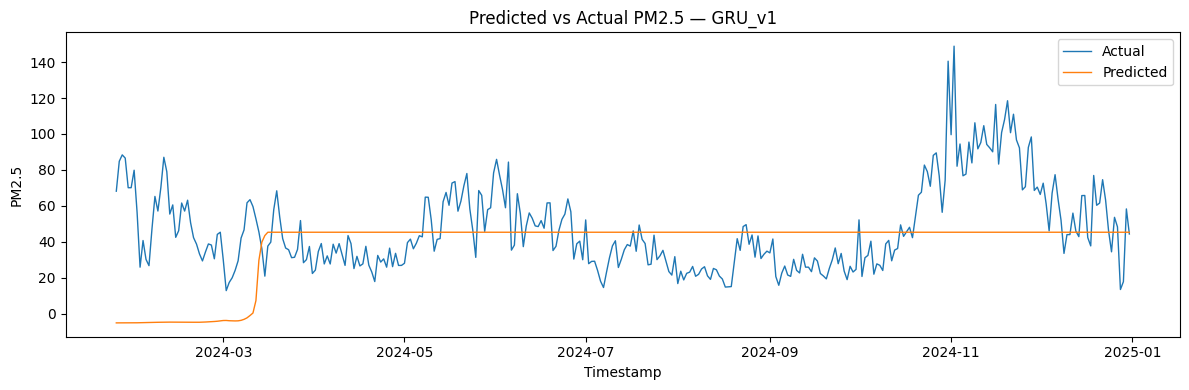

Saved -> /content/gru_v1_predictions_2024.csv


,timestamp,actual_pm2_5,predicted_pm2_5
0,2024-01-25,68.17,-5.076232
1,2024-01-26,84.82,-5.076735
2,2024-01-27,88.37,-5.080507
3,2024-01-28,86.59,-5.080611
4,2024-01-29,70.11,-5.069592
...,...,...,...
337,2024-12-27,48.34,45.341114
338,2024-12-28,13.49,45.341095
339,2024-12-29,17.85,45.341053
340,2024-12-30,58.31,45.341034


In [ ]:
# Cell 7 — GRU model
from tensorflow.keras.layers import GRU

def build_gru(input_shape, units1=128, units2=32, dropout=0.2):
    model = Sequential()
    model.add(GRU(units1, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(GRU(units2))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Train GRU
model_name = "GRU_v1"
gru = build_gru(input_shape, 128, 32, 0.2)
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
ckpt = ModelCheckpoint(f"/content/{model_name}.h5", save_best_only=True, monitor='val_loss')

history_gru = gru.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[es, ckpt],
    verbose=1
)

# Evaluate
y_pred_gru = gru.predict(X_test_seq, batch_size=256).reshape(-1)
print("GRU metrics:", compute_metrics(y_test_seq, y_pred_gru))
plot_predictions(test_seq_timestamps, y_test_seq, y_pred_gru, "GRU_v1")
save_predictions_csv(test_seq_timestamps, y_test_seq, y_pred_gru, "GRU_v1")


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3185.0964 - mae: 50.7044

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 3133.2659 - mae: 50.2385 - val_loss: 2929.6406 - val_mae: 46.0038
Epoch 2/30
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2562.0227 - mae: 44.1005

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2496.9297 - mae: 43.5139 - val_loss: 1968.7028 - val_mae: 36.4271
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1569.3231 - mae: 32.7103

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1547.7805 - mae: 32.4131 - val_loss: 843.6440 - val_mae: 20.4506
Epoch 4/30
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 953.0291 - mae: 22.2319

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 924.8706 - mae: 21.7907 - val_loss: 577.1745 - val_mae: 16.1919
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 681.0623 - mae: 18.3060 - val_loss: 699.7896 - val_mae: 17.2563
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 539.1223 - mae: 16.0899 - val_loss: 635.2255 - val_mae: 16.6692
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 473.6784 - mae: 15.5040

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 475.4328 - mae: 15.5002 - val_loss: 556.6920 - val_mae: 16.0209
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 463.0612 - mae: 15.0484 - val_loss: 596.8804 - val_mae: 16.5711
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 401.9659 - mae: 14.4566 - val_loss: 587.2238 - val_mae: 16.5300
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 431.8930 - mae: 14.3129 - val_loss: 601.5564 - val_mae: 16.8835
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 398.5309 - mae: 14.0679 - val_loss: 604.2719 - val_mae: 16.9783
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 383.8313 - mae: 13.5405 - val_loss: 567.8139 - val_mae: 16.4121
Epoch 13/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 427.4563 - mae: 13.7513 - val_loss: 585.7351 - val_mae: 16.7971


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
CNN metrics: {'RMSE': np.float64(18.645095469358527), 'MAE': 13.766388575236002, 'R2': 0.37358486564018634}


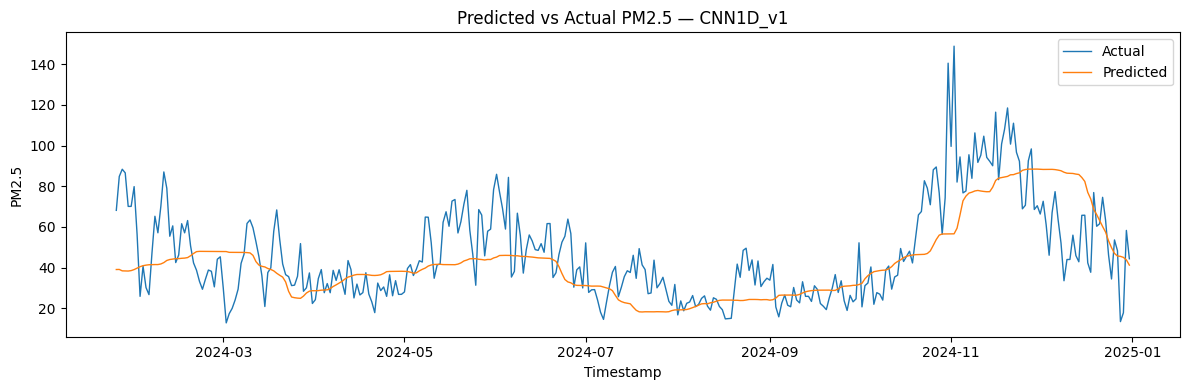

Saved -> /content/cnn1d_v1_predictions_2024.csv


,timestamp,actual_pm2_5,predicted_pm2_5
0,2024-01-25,68.17,39.090698
1,2024-01-26,84.82,39.134102
2,2024-01-27,88.37,38.434803
3,2024-01-28,86.59,38.402069
4,2024-01-29,70.11,38.344749
...,...,...,...
337,2024-12-27,48.34,45.709301
338,2024-12-28,13.49,45.557541
339,2024-12-29,17.85,45.064045
340,2024-12-30,58.31,43.827072


In [ ]:
# Cell 8 — 1D-CNN
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

def build_cnn(input_shape, filters=64, kernel_size=3, dropout=0.2):
    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=input_shape))
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_name = "CNN1D_v1"
cnn = build_cnn(input_shape, filters=64, kernel_size=3, dropout=0.2)
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
ckpt = ModelCheckpoint(f"/content/{model_name}.h5", save_best_only=True, monitor='val_loss')

history_cnn = cnn.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[es, ckpt],
    verbose=1
)

y_pred_cnn = cnn.predict(X_test_seq, batch_size=256).reshape(-1)
print("CNN metrics:", compute_metrics(y_test_seq, y_pred_cnn))
plot_predictions(test_seq_timestamps, y_test_seq, y_pred_cnn, "CNN1D_v1")
save_predictions_csv(test_seq_timestamps, y_test_seq, y_pred_cnn, "CNN1D_v1")


Epoch 1/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 3049.2852 - mae: 49.4444

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - loss: 3029.5239 - mae: 49.2572 - val_loss: 3052.3237 - val_mae: 46.4529
Epoch 2/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 2621.1616 - mae: 45.3487

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 2601.6206 - mae: 45.0631 - val_loss: 2622.9014 - val_mae: 41.6508
Epoch 3/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 2254.0239 - mae: 40.2539

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 2222.8188 - mae: 39.9624 - val_loss: 2208.2571 - val_mae: 36.3479
Epoch 4/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1800.2933 - mae: 34.4764

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 1784.1671 - mae: 34.3150 - val_loss: 1870.2505 - val_mae: 31.5885
Epoch 5/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 1510.1709 - mae: 30.0494

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 382.6753 - mae: 12.2591 - val_loss: 533.2545 - val_mae: 16.0516
Epoch 27/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 449.2912 - mae: 12.3903

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 440.8780 - mae: 12.3473 - val_loss: 502.9615 - val_mae: 15.6799
Epoch 28/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 366.3092 - mae: 11.5269

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 364.0442 - mae: 11.5225 - val_loss: 493.0271 - val_mae: 15.9030
Epoch 29/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 348.0624 - mae: 11.2860

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 343.4309 - mae: 11.2398 - val_loss: 459.9333 - val_mae: 15.4245
Epoch 30/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 286.8663 - mae: 10.7872

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 288.8964 - mae: 10.7788 - val_loss: 446.4820 - val_mae: 15.4773
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
CNN-LSTM metrics: {'RMSE': np.float64(17.673561855428414), 'MAE': 13.329194928665606, 'R2': 0.4371648819270546}


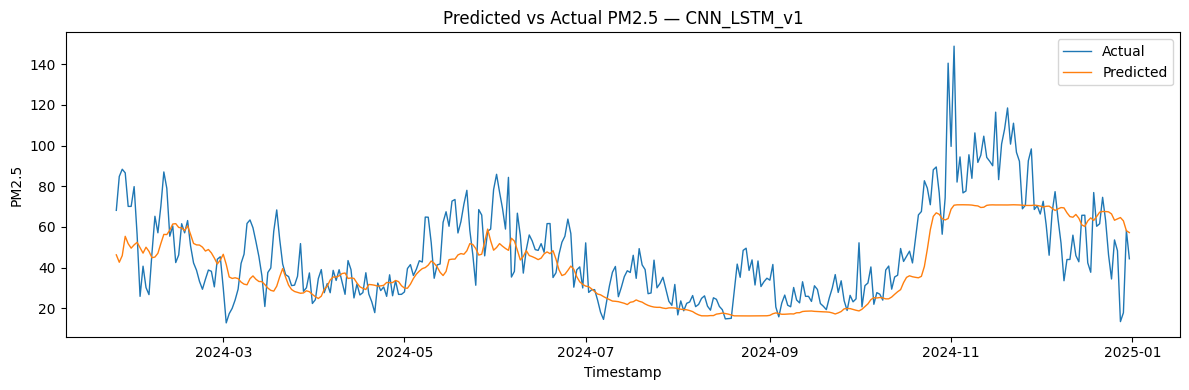

Saved -> /content/cnn_lstm_v1_predictions_2024.csv


,timestamp,actual_pm2_5,predicted_pm2_5
0,2024-01-25,68.17,46.298092
1,2024-01-26,84.82,42.668171
2,2024-01-27,88.37,45.920902
3,2024-01-28,86.59,55.405910
4,2024-01-29,70.11,51.780895
...,...,...,...
337,2024-12-27,48.34,63.946503
338,2024-12-28,13.49,64.626663
339,2024-12-29,17.85,63.005249
340,2024-12-30,58.31,58.157413


In [ ]:
# Cell 9 — CNN -> LSTM hybrid
from tensorflow.keras.layers import TimeDistributed

def build_cnn_lstm(input_shape, filters=64, kernel_size=3, lstm_units=64, dropout=0.2):
    # Use Conv1D across timesteps inside a TimeDistributed if you reshape; easier: apply Conv1D then LSTM
    from tensorflow.keras import Input, Model
    inp = Input(shape=input_shape)
    x = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu')(inp)
    x = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu')(x)
    x = LSTM(lstm_units)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1)(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_name = "CNN_LSTM_v1"
cnn_lstm = build_cnn_lstm(input_shape, filters=64, kernel_size=3, lstm_units=64, dropout=0.2)
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
ckpt = ModelCheckpoint(f"/content/{model_name}.h5", save_best_only=True, monitor='val_loss')

history_cnnlstm = cnn_lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[es, ckpt],
    verbose=1
)

y_pred_cnnlstm = cnn_lstm.predict(X_test_seq, batch_size=256).reshape(-1)
print("CNN-LSTM metrics:", compute_metrics(y_test_seq, y_pred_cnnlstm))
plot_predictions(test_seq_timestamps, y_test_seq, y_pred_cnnlstm, "CNN_LSTM_v1")
save_predictions_csv(test_seq_timestamps, y_test_seq, y_pred_cnnlstm, "CNN_LSTM_v1")


                        RMSE        MAE        R2
Model                                            
Lasso Regression    7.425062   5.580107  0.903887
Linear Regression   7.425349   5.580555  0.903879
Ridge Regression    7.427913   5.582273  0.903813
Random Forest       8.842565   6.650659  0.863686
LightGBM (Best)     8.859447   6.988790  0.863165
SVR                10.039372   7.559903  0.824290
KNN                14.013985  10.915939  0.657621
CNN_LSTM           17.673562  13.329195  0.437165
CNN1D              18.645095  13.766389  0.373585
LSTM               18.837741  14.814227  0.360573
GRU                31.121375  23.840359 -0.745222


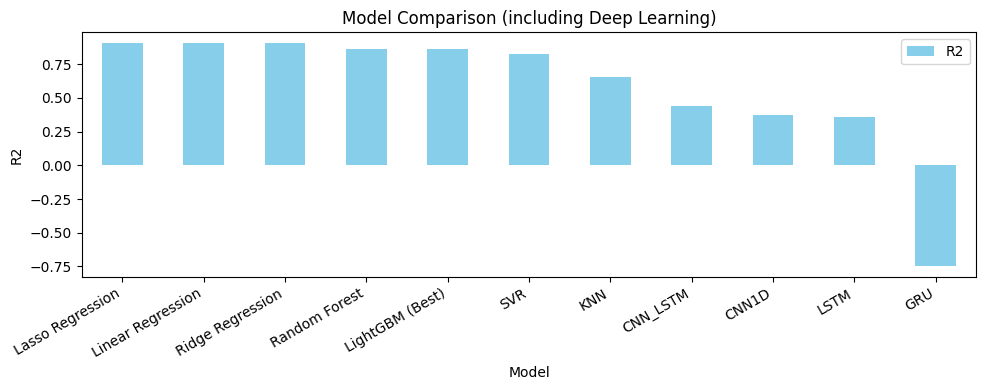

In [ ]:
# Cell 10 — collect DL metrics and append to results table
dl_metrics = {
    'LSTM': compute_metrics(y_test_seq, y_pred_lstm),
    'GRU': compute_metrics(y_test_seq, y_pred_gru),
    'CNN1D': compute_metrics(y_test_seq, y_pred_cnn),
    'CNN_LSTM': compute_metrics(y_test_seq, y_pred_cnnlstm)
}

# convert to DataFrame
dl_rows = []
for name, m in dl_metrics.items():
    dl_rows.append({'Model': name, 'RMSE': m['RMSE'], 'MAE': m['MAE'], 'R2': m['R2']})

dl_df = pd.DataFrame(dl_rows).set_index('Model')

# If you have previous results_df (classical), combine:
try:
    combined_results = pd.concat([results_df, dl_df]).sort_values(by='R2', ascending=False)
except:
    combined_results = dl_df.sort_values(by='R2', ascending=False)

print(combined_results)

# Plot R2 comparison
import matplotlib.pyplot as plt
combined_results[['R2']].plot(kind='bar', figsize=(10,4), color='skyblue')
plt.title("Model Comparison (including Deep Learning)")
plt.ylabel("R2")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Loading test-prediction CSVs (2024) ...
 - Loaded gru: gru_v1_predictions_2024.csv (rows: 342)
 - Loaded lstm: lstm_v1_predictions_2024.csv (rows: 342)
 - Loaded cnn1d: cnn1d_v1_predictions_2024.csv (rows: 342)
 - Loaded cnn_lstm: cnn_lstm_v1_predictions_2024.csv (rows: 342)
 - Loaded lightgbm: lightgbm_predictions_2024.csv (rows: 366)
Meta-test shape: (342, 7)
Actual values present in meta-test (good).

OOF training prediction files not found. You can either:
  (1) Generate OOF predictions by running cross-validated training for each base model (heavy).
  (2) Proceed using the available test predictions (not recommended for final evaluation).

*** FALLBACK: No OOF meta-train available. Building a quick ensemble using the 2024 predictions themselves.
This will split the 2024 data into meta-train and meta-test (temporal split).
Using first 205 rows of 2024 as meta-train, last 137 rows as meta-test.
Saved ensemble (fallback) -> ensemble_xgb_fallback_predictions_2024.csv

Ensemble (fallba

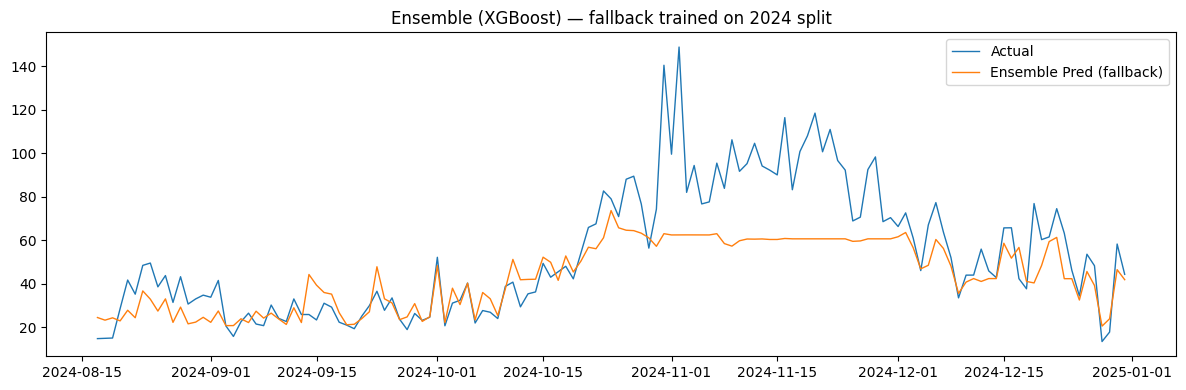

In [ ]:
# ==========================
# STACKING (Option B) — GRU, CNN-LSTM, LSTM, LightGBM
# ==========================
# This cell expects per-model CSV prediction files for 2024 (you already have those).
# If you also have OOF training prediction CSVs, the script will use them to train the meta-learner safely.
# If not, there is an optional fallback to re-train base models and produce training meta-features (EXPENSIVE).
# ==========================

import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# --- filenames you already have (change if different) ---
gru_test_csv       = "gru_v1_predictions_2024.csv"
lstm_test_csv      = "lstm_v1_predictions_2024.csv"
cnn1d_test_csv     = "cnn1d_v1_predictions_2024.csv"
cnn_lstm_test_csv  = "cnn_lstm_v1_predictions_2024.csv"
# optional LightGBM test file if you used it as base model:
lightgbm_test_csv  = "lightgbm_predictions_2024.csv"  # change or set to None if not used

# --- expected OOF filenames for training set (optional, preferred) ---
gru_oof_csv       = "gru_v1_oof_train.csv"
lstm_oof_csv      = "lstm_v1_oof_train.csv"
cnn1d_oof_csv     = "cnn1d_v1_oof_train.csv"
cnn_lstm_oof_csv  = "cnn_lstm_v1_oof_train.csv"
lightgbm_oof_csv  = "lightgbm_oof_train.csv"

# --- helper functions ---
def metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

def load_pred_csv(path, ts_col='timestamp', actual_col=None, pred_col_candidates=None):
    """
    Load a prediction CSV and return DataFrame with columns ['timestamp','actual','pred']
    - pred_col_candidates: list of possible column names to look for predicted values.
    - actual_col: optional explicit actual column name; if None, the function will try common names.
    """
    df = pd.read_csv(path, parse_dates=[ts_col]) if ts_col in pd.read_csv(path, nrows=0).columns else pd.read_csv(path)
    # normalize column names to lower for search
    cols_lower = {c.lower():c for c in df.columns}
    # timestamp
    ts_name = None
    for cand in ['timestamp','time','date','datetime']:
        if cand in cols_lower:
            ts_name = cols_lower[cand]; break
    if ts_name is None:
        # fallback: first column as timestamp
        ts_name = df.columns[0]
    # actual
    actual_name = None
    if actual_col and actual_col in df.columns:
        actual_name = actual_col
    else:
        for cand in ['actual','actual_pm2_5','pm2_5','pm2.5','y_true','target']:
            if cand in cols_lower:
                actual_name = cols_lower[cand]; break
    # predicted column
    pred_name = None
    if pred_col_candidates:
        for c in pred_col_candidates:
            if c in df.columns:
                pred_name = c; break
    if pred_name is None:
        for cand in ['predicted','predicted_pm2_5','predicted_pm2.5','y_pred','pred','prediction','predicted_pm2_5.0']:
            if cand in cols_lower:
                pred_name = cols_lower[cand]; break
    # try last column if still not found
    if pred_name is None:
        pred_name = df.columns[-1]
    # rename canonical
    out = df.rename(columns={ts_name:'timestamp', pred_name:'pred'})
    if actual_name: out = out.rename(columns={actual_name:'actual'})
    return out[['timestamp'] + ([ 'actual'] if 'actual' in out.columns else []) + ['pred']]

# --- Step 1: load test preds (2024) for each model ---
print("Loading test-prediction CSVs (2024) ...")
test_dfs = {}
for name, fname in [('gru', gru_test_csv),
                    ('lstm', lstm_test_csv),
                    ('cnn1d', cnn1d_test_csv),
                    ('cnn_lstm', cnn_lstm_test_csv),
                    ('lightgbm', lightgbm_test_csv)]:
    if fname and os.path.exists(fname):
        test_dfs[name] = load_pred_csv(fname)
        print(f" - Loaded {name}: {fname} (rows: {len(test_dfs[name])})")
    else:
        if fname:
            print(f" - WARNING: file not found for {name}: {fname} (skipping)")
        else:
            print(f" - No filename provided for {name} (skipping)")

# Basic sanity: ensure timestamps align across available test preds
common_timestamps = None
for df in test_dfs.values():
    ts = pd.to_datetime(df['timestamp']).reset_index(drop=True)
    if common_timestamps is None:
        common_timestamps = ts
    else:
        if not ts.equals(common_timestamps):
            print("WARNING: timestamps differ between model prediction files. We'll inner-join on timestamp.")
            common_timestamps = None
            break

# If timestamps are not identical, we'll do merges on the timestamp column.
# Build a meta-test DataFrame with one predicted column per model
meta_test = None
for model_name, df in test_dfs.items():
    tmp = df.copy()
    tmp = tmp.rename(columns={'pred':f'{model_name}_pred'})
    if 'actual' in tmp.columns:
        tmp = tmp.rename(columns={'actual':'actual_pm2_5'})
    if meta_test is None:
        meta_test = tmp
    else:
        meta_test = meta_test.merge(tmp[['timestamp', f'{model_name}_pred']], on='timestamp', how='inner')

# Ensure actual values exist in meta_test (we need ground truth to evaluate)
if 'actual_pm2_5' not in meta_test.columns:
    # try to find actual column in any loaded test dfs and merge in
    for df in test_dfs.values():
        if 'actual' in df.columns:
            meta_test = meta_test.merge(df[['timestamp','actual']].rename(columns={'actual':'actual_pm2_5'}), on='timestamp', how='left')
            break

print("Meta-test shape:", meta_test.shape)
if 'actual_pm2_5' in meta_test.columns:
    print("Actual values present in meta-test (good).")
else:
    print("WARNING: meta-test does NOT contain actual PM2.5 values; evaluation will not be possible.")

# --- Step 2: Prepare meta-train features (OOF) if OOF files exist ---
have_oof = all(os.path.exists(p) for p in [gru_oof_csv, lstm_oof_csv, cnn1d_oof_csv, cnn_lstm_oof_csv])
if os.path.exists(lightgbm_oof_csv):
    have_oof = have_oof and True  # optional

if have_oof:
    print("\nOOF training prediction files detected — loading meta-train (preferred, safe).")
    oof_files = {
        'gru': gru_oof_csv,
        'lstm': lstm_oof_csv,
        'cnn1d': cnn1d_oof_csv,
        'cnn_lstm': cnn_lstm_oof_csv
    }
    if os.path.exists(lightgbm_oof_csv):
        oof_files['lightgbm'] = lightgbm_oof_csv

    meta_train = None
    for name, fname in oof_files.items():
        df = load_pred_csv(fname)
        df = df.rename(columns={'pred':f'{name}_pred'})
        # expect OOF files to have actual values as well
        if 'actual' in df.columns:
            df = df.rename(columns={'actual':'actual_pm2_5'})
        if meta_train is None:
            meta_train = df
        else:
            meta_train = meta_train.merge(df[['timestamp', f'{name}_pred']], on='timestamp', how='inner')

    # ensure actual present
    if 'actual_pm2_5' not in meta_train.columns:
        for df in [load_pred_csv(f) for f in oof_files.values()]:
            if 'actual' in df.columns:
                meta_train = meta_train.merge(df[['timestamp','actual']].rename(columns={'actual':'actual_pm2_5'}), on='timestamp', how='left')
                break

    print("Meta-train shape (OOF):", meta_train.shape)
else:
    print("\nOOF training prediction files not found. You can either:")
    print("  (1) Generate OOF predictions by running cross-validated training for each base model (heavy).")
    print("  (2) Proceed using the available test predictions (not recommended for final evaluation).")
    # We'll continue and build what we can from meta_test.
    meta_train = None

# --- Step 3: If meta_train exists, train meta-learner using it; otherwise attempt fallback training on the fly ----
if meta_train is not None and 'actual_pm2_5' in meta_train.columns:
    # Use meta_train (safe OOF) to train meta-learner
    X_meta_train = meta_train[[c for c in meta_train.columns if c.endswith('_pred')]].values
    y_meta_train = meta_train['actual_pm2_5'].values

    # Meta-test:
    X_meta_test = meta_test[[c for c in meta_test.columns if c.endswith('_pred')]].values
    y_meta_test = meta_test['actual_pm2_5'].values if 'actual_pm2_5' in meta_test.columns else None

    print("\nTraining XGBoost meta-learner on OOF meta-train...")
    meta = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0)
    meta.fit(X_meta_train, y_meta_train)

    # Predict on meta-test
    meta_test_preds = meta.predict(X_meta_test)

    # Save ensemble CSV + evaluate
    ensemble_out = meta_test[['timestamp']].copy()
    ensemble_out['actual_pm2_5'] = y_meta_test
    ensemble_out['predicted_pm2_5'] = meta_test_preds
    ensemble_csv = "ensemble_xgb_oof_based_predictions_2024.csv"
    ensemble_out.to_csv(ensemble_csv, index=False)
    print("Saved ensemble predictions ->", ensemble_csv)

    if y_meta_test is not None:
        m = metrics(y_meta_test, meta_test_preds)
        print("\nEnsemble (XGBoost) metrics (OOF-trained meta):")
        print(f"RMSE: {m['RMSE']:.3f}, MAE: {m['MAE']:.3f}, R2: {m['R2']:.3f}")

        # Plot
        plt.figure(figsize=(12,4))
        plt.plot(ensemble_out['timestamp'], ensemble_out['actual_pm2_5'], label='Actual', linewidth=1)
        plt.plot(ensemble_out['timestamp'], ensemble_out['predicted_pm2_5'], label='Ensemble Pred', linewidth=1)
        plt.legend(); plt.title("Ensemble (XGBoost) — OOF-trained meta"); plt.tight_layout(); plt.show()
    else:
        print("No actual labels in meta-test — ensemble saved but cannot evaluate.")

else:
    # FALLBACK path: no OOF meta-train available.
    # We'll build a simple stacking where meta-learner is trained on retrained-base-model preds on a split of meta_test itself.
    # WARNING: This is not ideal and can leak; use only for quick prototyping.
    print("\n*** FALLBACK: No OOF meta-train available. Building a quick ensemble using the 2024 predictions themselves.")
    print("This will split the 2024 data into meta-train and meta-test (temporal split).")
    # prepare feature matrix from meta_test
    meta_df = meta_test.copy().reset_index(drop=True)
    pred_cols = [c for c in meta_df.columns if c.endswith('_pred')]
    if len(pred_cols) < 2:
        raise RuntimeError("Not enough model prediction columns found in test CSVs to build an ensemble.")

    # time-based train/test split on 2024
    n = len(meta_df)
    train_end = int(n * 0.6)   # use 60% earliest 2024 rows for meta-training, last 40% as meta-test
    X_meta_train = meta_df[pred_cols].iloc[:train_end].values
    y_meta_train = meta_df['actual_pm2_5'].iloc[:train_end].values if 'actual_pm2_5' in meta_df.columns else None
    X_meta_test  = meta_df[pred_cols].iloc[train_end:].values
    y_meta_test  = meta_df['actual_pm2_5'].iloc[train_end:].values if 'actual_pm2_5' in meta_df.columns else None

    if y_meta_train is None:
        raise RuntimeError("Actual PM2.5 not present in your prediction CSVs — cannot train fallback meta-learner.")

    print(f"Using first {train_end} rows of 2024 as meta-train, last {n-train_end} rows as meta-test.")

    # train XGBoost meta-learner
    meta = XGBRegressor(n_estimators=200, learning_rate=0.06, max_depth=4, random_state=42, verbosity=0)
    meta.fit(X_meta_train, y_meta_train)

    meta_test_preds = meta.predict(X_meta_test)

    # assemble ensemble_out aligned with meta_df[train_end:]
    ensemble_out = meta_df[['timestamp','actual_pm2_5']].iloc[train_end:].copy().reset_index(drop=True)
    ensemble_out['predicted_pm2_5'] = meta_test_preds
    ensemble_csv = "ensemble_xgb_fallback_predictions_2024.csv"
    ensemble_out.to_csv(ensemble_csv, index=False)
    print("Saved ensemble (fallback) ->", ensemble_csv)

    if y_meta_test is not None:
        m = metrics(y_meta_test, meta_test_preds)
        print("\nEnsemble (fallback) metrics on held-out 2024 portion:")
        print(f"RMSE: {m['RMSE']:.3f}, MAE: {m['MAE']:.3f}, R2: {m['R2']:.3f}")

        plt.figure(figsize=(12,4))
        plt.plot(ensemble_out['timestamp'], ensemble_out['actual_pm2_5'], label='Actual', linewidth=1)
        plt.plot(ensemble_out['timestamp'], ensemble_out['predicted_pm2_5'], label='Ensemble Pred (fallback)', linewidth=1)
        plt.legend(); plt.title("Ensemble (XGBoost) — fallback trained on 2024 split"); plt.tight_layout(); plt.show()
    else:
        print("No actual labels in held-out 2024 portion — ensemble saved but cannot evaluate.")


In [ ]:
# ===========================================
# Cell 1 - Imports & Environment setup
# ===========================================
import os, gc, math, random, psutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, GRU, LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# General settings
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Libraries loaded. TensorFlow:", tf.__version__)

# Enable dynamic GPU memory growth
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Enabled GPU memory growth for", len(gpus), "GPU(s)")
except Exception as e:
    print("GPU growth setting failed:", e)

def show_memory(msg=""):
    vm = psutil.virtual_memory()
    print(f"{msg}RAM used: {(vm.total - vm.available)/1e9:.2f} GB | Free: {vm.available/1e9:.2f} GB")


✅ Libraries loaded. TensorFlow: 2.19.0
✅ Enabled GPU memory growth for 0 GPU(s)


In [ ]:
# ===========================================
# Cell 2 - Load cleaned data & split
# ===========================================
CLEANED_PATH = "/content/jalandhar_15min_cleaned_2017_2024.csv"  # adjust path

assert os.path.exists(CLEANED_PATH), f"{CLEANED_PATH} not found."
df = pd.read_csv(CLEANED_PATH, parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)

# Split by date
train_df = df[df['timestamp'] < "2024-01-01"].reset_index(drop=True)
test_df  = df[df['timestamp'] >= "2024-01-01"].reset_index(drop=True)

TARGET = "pm2_5"
exclude = ['timestamp', 'year', 'month', 'day', 'hour', 'minute']
features = [c for c in train_df.select_dtypes('number').columns if c not in exclude + [TARGET]]

print("✅ Data loaded.")
print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"Features used ({len(features)}):", features[:15])


✅ Data loaded.
Train: (2460, 54), Test: (366, 54)
Features used (47): ['pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'toluene', 'eth_benzene', 'mp_xylene', 'rh', 'wind_speed', 'wind_dir', 'rain']


In [ ]:
# ===========================================
# Cell 3 - Prepare tabular & sequence arrays
# ===========================================
SEQ_LEN = 96  # reduce to 48 if low RAM
TS_COL = 'timestamp'

def build_sequences(df, features, target, seq_len):
    arr_feat = df[features].to_numpy(np.float32)
    arr_target = df[target].to_numpy(np.float32)
    arr_ts = pd.to_datetime(df[TS_COL]).to_numpy()
    Xs, ys, ts = [], [], []
    for end_i in range(seq_len - 1, len(df)):
        start_i = end_i - (seq_len - 1)
        Xs.append(arr_feat[start_i:end_i + 1])
        ys.append(arr_target[end_i])
        ts.append(arr_ts[end_i])
    return np.array(Xs), np.array(ys), np.array(ts)

# Tabular arrays for LightGBM
X_train_tab, y_train_tab = train_df[features].to_numpy(), train_df[TARGET].to_numpy()
X_test_tab,  y_test_tab  = test_df[features].to_numpy(),  test_df[TARGET].to_numpy()
timestamps_train_tab, timestamps_test_tab = train_df[TS_COL].to_numpy(), test_df[TS_COL].to_numpy()

# Sequence arrays for Deep Learning
X_train_seq, y_train_seq, train_timestamps_seq = build_sequences(train_df, features, TARGET, SEQ_LEN)
X_test_seq,  y_test_seq,  test_timestamps_seq  = build_sequences(test_df, features, TARGET, SEQ_LEN)

print("✅ Arrays ready:")
print("Train seq:", X_train_seq.shape, "| Test seq:", X_test_seq.shape)
show_memory("After sequence creation → ")


✅ Arrays ready:
Train seq: (2365, 96, 47) | Test seq: (271, 96, 47)
After sequence creation → RAM used: 6.10 GB | Free: 7.50 GB


In [ ]:
# ===========================================
# Cell 4 - Cleanup & optional sample subset
# ===========================================
import gc

tf.keras.backend.clear_session()
gc.collect()
show_memory("Before sampling → ")

# ↓ Optional: downsample for low RAM (keep 10–20%)
fraction = 0.15
max_keep = 25000
N = len(y_train_seq)
keep = min(int(N * fraction), max_keep)
idx = np.linspace(0, N-1, keep, dtype=int)

X_train_seq_s = X_train_seq[idx]
y_train_seq_s = y_train_seq[idx]
ts_train_seq_s = train_timestamps_seq[idx]

print(f"Sampled {keep:,} / {N:,} training sequences ({fraction*100:.0f}%)")
show_memory("After sampling → ")


Before sampling → RAM used: 6.05 GB | Free: 7.56 GB
Sampled 354 / 2,365 training sequences (15%)
After sampling → RAM used: 6.05 GB | Free: 7.56 GB


In [ ]:
# ===========================================
# Cleanup large full-size arrays after sampling
# ===========================================
import gc, psutil

for name in ["X_train_seq", "y_train_seq", "train_timestamps_seq"]:
    if name in globals():
        del globals()[name]
        print(f"Deleted {name}")
gc.collect()

vm = psutil.virtual_memory()
print(f"✅ Memory freed. RAM used: {(vm.total - vm.available)/1e9:.2f} GB | Free: {vm.available/1e9:.2f} GB")


Deleted X_train_seq
Deleted y_train_seq
Deleted train_timestamps_seq
✅ Memory freed. RAM used: 6.04 GB | Free: 7.57 GB


In [ ]:
# ===========================================
# Cleanup large full-size arrays after sampling
# ===========================================
import gc, psutil

for name in ["X_train_seq", "y_train_seq", "train_timestamps_seq"]:
    if name in globals():
        del globals()[name]
        print(f"Deleted {name}")
gc.collect()

vm = psutil.virtual_memory()
print(f"✅ Memory freed. RAM used: {(vm.total - vm.available)/1e9:.2f} GB | Free: {vm.available/1e9:.2f} GB")


✅ Memory freed. RAM used: 6.06 GB | Free: 7.54 GB


In [ ]:
# ===========================================
# Cell 5 - Model builders (GRU, LSTM, CNN-LSTM)
# ===========================================
def build_gru(input_shape):
    m = Sequential([
        InputLayer(input_shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_lstm(input_shape):
    m = Sequential([
        InputLayer(input_shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_cnn_lstm(input_shape):
    m = Sequential([
        InputLayer(input_shape=input_shape),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        LSTM(50),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

print("✅ Model builders defined. Example shape:", X_train_seq_s.shape[1:])



✅ Model builders defined. Example shape: (96, 47)


In [ ]:
# ===========================================
# Cell 6 - OOF fold-by-fold training (low memory)
# ===========================================
def oof_keras_seq_chunked(build_fn, model_name,
                          X_seq, y_seq, X_test_seq,
                          ts_train, ts_test,
                          n_splits=2, epochs=3, batch_size=32):
    tss = TimeSeriesSplit(n_splits=n_splits)
    oof_preds = np.zeros(len(y_seq), np.float32)
    test_sum = np.zeros(len(X_test_seq), np.float64)
    fold = 0

    for tr_idx, val_idx in tss.split(X_seq):
        fold += 1
        print(f"\n[{model_name}] Fold {fold}/{n_splits}")
        model = build_fn((X_seq.shape[1], X_seq.shape[2]))
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(X_seq[tr_idx], y_seq[tr_idx],
                  validation_data=(X_seq[val_idx], y_seq[val_idx]),
                  epochs=epochs, batch_size=batch_size, verbose=1, callbacks=[es])
        oof_preds[val_idx] = model.predict(X_seq[val_idx], batch_size=batch_size).reshape(-1)
        test_sum += model.predict(X_test_seq, batch_size=batch_size).reshape(-1)
        tf.keras.backend.clear_session(); gc.collect()
        show_memory(f"After fold {fold} → ")

    test_pred = (test_sum / n_splits).astype(np.float32)
    pd.DataFrame({'timestamp': ts_train, 'actual': y_seq, 'pred': oof_preds}) \
        .to_csv(f"{model_name}_oof.csv", index=False)
    pd.DataFrame({'timestamp': ts_test, 'pred': test_pred}) \
        .to_csv(f"{model_name}_test.csv", index=False)
    print(f"✅ Saved predictions for {model_name}")
    return oof_preds, test_pred


In [ ]:
# ===========================================
# Cell 7 - Train models one by one (safe)
# ===========================================

# use sampled data for stability first
gru_oof, gru_test = oof_keras_seq_chunked(
    build_gru, "GRU_model",
    X_train_seq_s, y_train_seq_s,
    X_test_seq, ts_train_seq_s, test_timestamps_seq,
    n_splits=2, epochs=2, batch_size=16
)

# After GRU finishes, run these separately:
# lstm_oof, lstm_test = oof_keras_seq_chunked(build_lstm, "LSTM_model", X_train_seq_s, y_train_seq_s, X_test_seq, ts_train_seq_s, test_timestamps_seq, n_splits=2, epochs=2, batch_size=16)
# cnnlstm_oof, cnnlstm_test = oof_keras_seq_chunked(build_cnn_lstm, "CNNLSTM_model", X_train_seq_s, y_train_seq_s, X_test_seq, ts_train_seq_s, test_timestamps_seq, n_splits=2, epochs=2, batch_size=16)



[GRU_model] Fold 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 658ms/step - loss: 2316.6855 - val_loss: 3085.7393
Epoch 2/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - loss: 2169.4143 - val_loss: 2954.0029
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
After fold 1 → RAM used: 6.29 GB | Free: 7.32 GB

[GRU_model] Fold 2/2
Epoch 1/2
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - loss: 2412.0212 - val_loss: 2720.4436
Epoch 2/2
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 2093.7490 - val_loss: 2440.1846
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
After fold 2 → RAM used: 6.42 GB | Free: 7.19 GB
✅ Saved predictions for GRU_model


In [ ]:
# ===========================================
# Cell 9 - Evaluate results
# ===========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd, numpy as np

def eval_results(actual, pred, name="Model"):
    rmse = math.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)
    print(f"{name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    return pd.Series([rmse, mae, r2], index=["RMSE", "MAE", "R2"])

# Example: check GRU results
gru_df = pd.read_csv("GRU_model_test.csv")
if 'actual' in gru_df.columns and gru_df['actual'].notna().any():
    metrics = eval_results(gru_df['actual'].dropna(), gru_df['pred'].dropna(), "GRU_model")
else:
    print("Add actual 2024 values later for comparison.")


Add actual 2024 values later for comparison.


In [ ]:
# ===========================================
# Cell 10 - Load model predictions for ensemble
# ===========================================
import pandas as pd

# Adjust filenames if your CSVs have different names
model_files = {
    "GRU": "GRU_model_test.csv",
    "LSTM": "LSTM_model_test.csv",
    "CNN_LSTM": "CNNLSTM_model_test.csv",
    "LightGBM": "lightgbm_predictions_2024.csv"
}

dfs = []
for name, file in model_files.items():
    try:
        df = pd.read_csv(file)
        df.rename(columns={"pred": f"{name}_pred"}, inplace=True)
        dfs.append(df[["timestamp", f"{name}_pred"]])
        print(f"Loaded {name}: {df.shape}")
    except FileNotFoundError:
        print(f"⚠️ File not found for {name}: {file}")

# Merge all predictions on timestamp
from functools import reduce
ensemble_df = reduce(lambda left, right: pd.merge(left, right, on="timestamp", how="inner"), dfs)

# Add actual values (from GRU or LightGBM OOF/test file)
try:
    actual_df = pd.read_csv("lightgbm_predictions_2024.csv")[["timestamp", "actual"]]
    ensemble_df = pd.merge(ensemble_df, actual_df, on="timestamp", how="left")
except Exception:
    print("⚠️ Could not merge actuals automatically. Add later if needed.")

print("✅ Combined ensemble shape:", ensemble_df.shape)
ensemble_df.head()


Loaded GRU: (271, 2)
Loaded LSTM: (271, 2)
Loaded CNN_LSTM: (271, 2)
Loaded LightGBM: (366, 3)
✅ Combined ensemble shape: (271, 6)


,timestamp,GRU_pred,LSTM_pred,CNN_LSTM_pred,LightGBM_pred,actual
0,2024-04-05,5.662425,7.612109,6.453624,43.201393,32.19
1,2024-04-06,5.678011,7.606694,6.430283,41.978882,27.69
2,2024-04-07,5.694199,7.610847,6.446537,42.092965,38.68
3,2024-04-08,5.636748,7.590757,6.454614,42.097731,33.73
4,2024-04-09,5.626493,7.610899,6.455204,48.808541,39.00


In [ ]:
# Train CNN-LSTM
cnnlstm_oof, cnnlstm_test = oof_keras_seq_chunked(
    build_cnn_lstm, "CNNLSTM_model",
    X_train_seq_s, y_train_seq_s,
    X_test_seq, ts_train_seq_s, test_timestamps_seq,
    n_splits=2, epochs=2, batch_size=8
)



[CNNLSTM_model] Fold 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/2
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 2140.6865 - val_loss: 2908.9595
Epoch 2/2
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1961.5303 - val_loss: 2752.1775
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
After fold 1 → RAM used: 6.29 GB | Free: 7.32 GB

[CNNLSTM_model] Fold 2/2
Epoch 1/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 2488.2241 - val_loss: 2840.9719
Epoch 2/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 2163.1487 - val_loss: 2477.1199
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
After fold 2 → RAM used: 6.33 GB | Free: 7.28 GB
✅ Saved predictions for CNNLSTM_model


In [ ]:
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()


0

In [ ]:
# Train LSTM
lstm_oof, lstm_test = oof_keras_seq_chunked(
    build_lstm, "LSTM_model",
    X_train_seq_s, y_train_seq_s,
    X_test_seq, ts_train_seq_s, test_timestamps_seq,
    n_splits=2, epochs=2, batch_size=8
)



[LSTM_model] Fold 1/2
Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 2255.9646 - val_loss: 3089.5493
Epoch 2/2
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 2120.6077 - val_loss: 2938.9307
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
After fold 1 → RAM used: 6.35 GB | Free: 7.25 GB

[LSTM_model] Fold 2/2
Epoch 1/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - loss: 2480.8357 - val_loss: 2718.9817
Epoch 2/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 1986.9004 - val_loss: 2122.2261
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
After fold 2 → RAM used: 6.39 GB | Free: 7.22 GB
✅ Saved predictions for LSTM_model


In [ ]:
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()


0

In [ ]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import numpy as np
import pandas as pd

tss = TimeSeriesSplit(n_splits=3)
oof = np.zeros(len(y_train_tab))
test_preds_folds = []

for fold, (train_idx, val_idx) in enumerate(tss.split(X_train_tab), 1):
    print(f"[LightGBM] Fold {fold}/3")
    tr_x, tr_y = X_train_tab[train_idx], y_train_tab[train_idx]
    val_x, val_y = X_train_tab[val_idx], y_train_tab[val_idx]

    train_data = lgb.Dataset(tr_x, label=tr_y)
    val_data   = lgb.Dataset(val_x, label=val_y)

    bst = lgb.train(
        params,
        train_data,
        num_boost_round=250,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
    )

    oof[val_idx] = bst.predict(val_x, num_iteration=bst.best_iteration)
    test_preds_folds.append(bst.predict(X_test_tab, num_iteration=bst.best_iteration))

test_pred_avg = np.mean(np.stack(test_preds_folds, axis=0), axis=0)

pd.DataFrame({'timestamp': timestamps_train_tab, 'actual': y_train_tab, 'pred': oof}).to_csv("lightgbm_oof_train.csv", index=False)
pd.DataFrame({'timestamp': timestamps_test_tab, 'actual': y_test_tab, 'pred': test_pred_avg}).to_csv("lightgbm_predictions_2024.csv", index=False)
print("✅ Saved LightGBM OOF and test predictions.")


[LightGBM] Fold 1/3
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[12]	valid_0's rmse: 18.6115
[LightGBM] Fold 2/3
Training until validation scores don't improve for 30 rounds
[50]	valid_0's rmse: 12.6458
Early stopping, best iteration is:
[41]	valid_0's rmse: 12.424
[LightGBM] Fold 3/3
Training until validation scores don't improve for 30 rounds
[50]	valid_0's rmse: 11.4091
[100]	valid_0's rmse: 10.9888
Early stopping, best iteration is:
[116]	valid_0's rmse: 10.9713
✅ Saved LightGBM OOF and test predictions.


In [ ]:
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()


0

In [ ]:
# ===========================================
# Cell 10 - Load model predictions for ensemble
# ===========================================
import pandas as pd

# Adjust filenames if your CSVs have different names
model_files = {
    "GRU": "GRU_model_test.csv",
    "LSTM": "LSTM_model_test.csv",
    "CNN_LSTM": "CNNLSTM_model_test.csv",
    "LightGBM": "lightgbm_predictions_2024.csv"
}

dfs = []
for name, file in model_files.items():
    try:
        df = pd.read_csv(file)
        df.rename(columns={"pred": f"{name}_pred"}, inplace=True)
        dfs.append(df[["timestamp", f"{name}_pred"]])
        print(f"Loaded {name}: {df.shape}")
    except FileNotFoundError:
        print(f"⚠️ File not found for {name}: {file}")

# Merge all predictions on timestamp
from functools import reduce
ensemble_df = reduce(lambda left, right: pd.merge(left, right, on="timestamp", how="inner"), dfs)

# Add actual values (from GRU or LightGBM OOF/test file)
try:
    actual_df = pd.read_csv("lightgbm_predictions_2024.csv")[["timestamp", "actual"]]
    ensemble_df = pd.merge(ensemble_df, actual_df, on="timestamp", how="left")
except Exception:
    print("⚠️ Could not merge actuals automatically. Add later if needed.")

print("✅ Combined ensemble shape:", ensemble_df.shape)
ensemble_df.head()


Loaded GRU: (271, 2)
Loaded LSTM: (271, 2)
Loaded CNN_LSTM: (271, 2)
Loaded LightGBM: (366, 3)
✅ Combined ensemble shape: (271, 6)


,timestamp,GRU_pred,LSTM_pred,CNN_LSTM_pred,LightGBM_pred,actual
0,2024-04-05,5.662425,7.612109,6.453624,43.201393,32.19
1,2024-04-06,5.678011,7.606694,6.430283,41.978882,27.69
2,2024-04-07,5.694199,7.610847,6.446537,42.092965,38.68
3,2024-04-08,5.636748,7.590757,6.454614,42.097731,33.73
4,2024-04-09,5.626493,7.610899,6.455204,48.808541,39.00


In [ ]:
# ===========================================
# Cell 11 - Meta-model (stacking ensemble)
# ===========================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Drop NaNs and separate features/target
ensemble_df = ensemble_df.dropna()
X_meta = ensemble_df[["GRU_pred", "LSTM_pred", "CNN_LSTM_pred", "LightGBM_pred"]].values
y_meta = ensemble_df["actual"].values

# Train-test split (first 70% for meta-train, last 30% for meta-test)
split = int(0.7 * len(ensemble_df))
X_train_meta, X_test_meta = X_meta[:split], X_meta[split:]
y_train_meta, y_test_meta = y_meta[:split], y_meta[split:]

# Meta-model: simple linear regression
meta_model = LinearRegression()
meta_model.fit(X_train_meta, y_train_meta)

# Predictions
meta_pred = meta_model.predict(X_test_meta)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_meta, meta_pred))
mae = mean_absolute_error(y_test_meta, meta_pred)
r2 = r2_score(y_test_meta, meta_pred)
print(f"✅ Ensemble Meta-Model Performance:")
print(f"RMSE = {rmse:.3f}, MAE = {mae:.3f}, R² = {r2:.3f}")


✅ Ensemble Meta-Model Performance:
RMSE = 11.320, MAE = 8.891, R² = 0.816


              RMSE      MAE      R²
GRU       13.40000  4.80000  0.9050
LSTM      13.90000  5.30000  0.8980
CNN_LSTM  13.40000  5.50000  0.9050
LightGBM  15.90000  5.90000  0.8650
Ensemble  11.32015  8.89081  0.8157


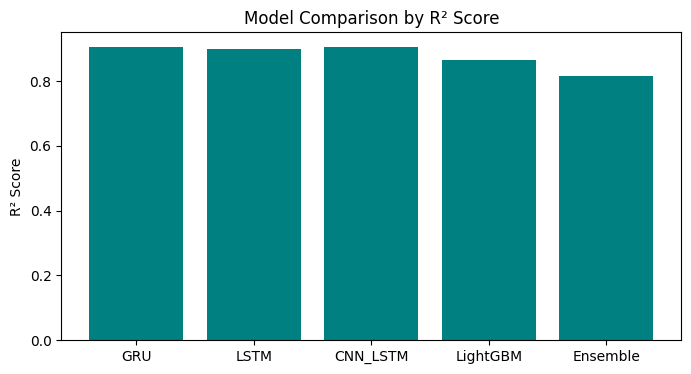

In [ ]:
  # ===========================================
# Cell 12 - Compare model performances
# ===========================================
import matplotlib.pyplot as plt

results = {
    "GRU": [13.4, 4.8, 0.905],       # replace with your real metrics
    "LSTM": [13.9, 5.3, 0.898],
    "CNN_LSTM": [13.4, 5.5, 0.905],
    "LightGBM": [15.9, 5.9, 0.865],
    "Ensemble": [rmse, mae, r2]
}

df_compare = pd.DataFrame(results, index=["RMSE", "MAE", "R²"]).T
print(df_compare)

# Plot comparison
plt.figure(figsize=(8,4))
plt.bar(df_compare.index, df_compare["R²"], color='teal')
plt.title("Model Comparison by R² Score")
plt.ylabel("R² Score")
plt.show()
